# Visualize paralog compensation and collateral loss results, including biological enrichments in hit pairs


In [143]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from matplotlib.lines import Line2D
from matplotlib_venn import venn3
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.stats import fisher_exact
from collections import Counter

# Functions and specs

In [144]:
coldict = {
    'compensation': "#00ABF5",
    'collateral_loss': "#FFBC1F",
    'non_hit': "grey",
    'Compensation': "#00ABF5",
    'Collateral loss': "#FFBC1F",
    'Non-hit': "grey",
    'SL': "#800000" 
}

In [145]:
colmap_allcats = {
    'prot': '#A96DAE',    
    'trans': '#C7A238',  
    'resid': '#5AACA8' 
}


# Function to blend colors
def blend_colors(color1, color2, ratio=0.5):
    rgb1 = mcolors.to_rgb(color1)
    rgb2 = mcolors.to_rgb(color2)
    blend = tuple([(1-ratio)*c1 + ratio*c2 for c1, c2 in zip(rgb1, rgb2)])
    return mcolors.to_hex(blend)

color_map_venns = {
    '100': colmap_allcats['prot'],
    '010': colmap_allcats['trans'],
    '001': colmap_allcats['resid'],
    '110': blend_colors(colmap_allcats['prot'], colmap_allcats['trans']),
    '101': blend_colors(colmap_allcats['prot'], colmap_allcats['resid']),
    '011': blend_colors(colmap_allcats['trans'], colmap_allcats['resid']),
    '111': blend_colors(blend_colors(colmap_allcats['prot'], colmap_allcats['trans']), colmap_allcats['resid'])
}

In [146]:
namedict = {'depmap_SL':'DepMap synthetic lethal', 
            'either_in_essential_CORUM_complex':'Either in essential CORUM complex',
           'SL_atleast2_CRISPR_screens':'Synthetic lethal in >1 combinatorial screen', 
           'SL_atleast1_CRISPRscreen':'Synthetic lethal in >=1 combinatorial screen',
           'either_in_CORUM_complex':'Either in CORUM complex',
           'both_in_same_CORUM_complex':'Both in same CORUM complex',
           'closest_paralogs_in_family':'Closest paralogs in family',
           'bg_jaccard':'Biogrid Jaccard index',
           'string_jaccard_physical': 'STRING Jaccard index', 
           'string_dc_physical':'STRING degree centrality',
           'conservation_score':'Conservation score', 
           'A2_median_neighbour_ess':'Median lost gene\nneighbour essentiality',
           'biogrid_dc':'Biogrid degree centrality',
           'sequence_identity':'Sequence identity',
           'family_size':'Family size',
           'coreg':'Coregulated by same transcription factor',
           'either_regulates_other':'Either paralog regulates other',
           'A1_length':'Paralog protein length',
           'A2_length':'Lost protein length', 
           'A1_perc_at_int':'% paralog residues\never at interface',
           'A2_perc_at_int':'% lost protein residues\never at interface', 
           'A1_hl':'Log10 paralog\nhalf life',
           'A2_hl':'Log10 lost protein\nhalf life',
           'A1_dis':'% paralog protein\ndisordered', 
           'A2_dis':'% lost protein\ndisordered',
           'A1_abundance':'Mean paralog\nabundance in GTEX', 
           'A2_abundance':'Mean lost protein\nabundance in GTEX'}


In [147]:
def generate_comp_CL_barchart(res_A1A2, filename, colormap, xlim=15,yticks=True):
    fig, ax = plt.subplots(figsize=(6, 4))  
    num_tested = res_A1A2.shape[0]
    num_comp = res_A1A2[res_A1A2.compensation].shape[0]
    num_CL = res_A1A2[res_A1A2.collateral_loss].shape[0]
    per_comp = round((num_comp / num_tested) * 100, 0)
    per_CL = round((num_CL / num_tested) * 100, 0)
    values = [per_CL, per_comp]
    values = [int(x) for x in values]
    counts = [num_CL, num_comp]
    ax.barh(['Collateral loss', 'Compensation'], values, color=[colormap['collateral_loss'], colormap['compensation']], alpha=0.7, edgecolor='black')
    ax.set_xlim(0,xlim)
    for index, (value, count) in enumerate(zip(values, counts)):
        ax.text(value + 0.5, index, f'{value}% ({count})', ha='left', va='center', fontsize=22)
    if xlim==15:
        ax.set_xticks(range(0, 20, 5))  # Reintroducing the xticks
    ax.set_xlabel(f'\n% of {len(res_A1A2)} paralog pairs tested', fontsize=22)  # Adding x-axis label    
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=22)
    if yticks== False:
        ax.set_yticks([])
    plt.savefig(f'../output/figures/{filename}_compCL.svg', dpi = 120, bbox_inches ='tight')
    plt.show()
    

In [148]:
def HAP1_boxplot(gene_pair, A1A2_df, data, colordict, show_points=True):
    A1A2_df['standard_gene_pair'] = A1A2_df['gene_pair'].apply(lambda x: '_'.join(x.split('_')[0:2]))
    A1A2_df['retained_clone'] = A1A2_df['gene_pair'].apply(lambda x: x.split('_')[-1] if len(x.split('_')) > 2 else '')
    A1, A2 = gene_pair.split('_')[0], gene_pair.split('_')[1]
    row = A1A2_df.loc[A1A2_df['standard_gene_pair'] == gene_pair].iloc[0]
    retained_clone = row['retained_clone']
    if retained_clone:
        full_gene_pair = f"{gene_pair}_{retained_clone}"
    else:
        full_gene_pair = gene_pair
    
    KO_data = data[full_gene_pair][0]
    wt_data = data[full_gene_pair][1]
    if A1A2_df.loc[A1A2_df['gene_pair'] == gene_pair, 'compensation'].values[0]:
        status = 'compensation'
    elif A1A2_df.loc[A1A2_df['gene_pair'] == gene_pair, 'collateral_loss'].values[0]:
        status = 'collateral_loss'
    else:
        status = 'non_hit'
    
    # Count non-NA measurements for each group
    wt_count = sum(~pd.isna(wt_data))
    ko_count = sum(~pd.isna(KO_data))
    
    fig, ax = plt.subplots(figsize=(4, 4.5))
    KO_color = colordict[status]
    df = pd.DataFrame({'Category': ['WT'] * len(wt_data) + ['KO'] * len(KO_data),
                       'Abundance': wt_data + KO_data})
    
    # Create the boxplot
    sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
                order=['WT', 'KO'],
                palette={'WT': 'white', 'KO': KO_color},
                linewidth=2.4, showfliers=False, showmeans=False, saturation=1,
                boxprops=dict(alpha=0.8), medianprops=dict(linewidth=2.4, color='black'))
    
    if show_points:
        sns.stripplot(x='Category', y='Abundance', data=df, order=['WT', 'KO'], color='grey', ax=ax, alpha=0.8, size=3, zorder=0)  
    ax.set_xlim(-0.6, 1.6)  
    
    # Update x-tick labels with gene name on first line, WT/KO with sample size on second
    ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)
    
    # Remove the separate x-axis label
    ax.set_xlabel('', fontsize=18)
    
    ax.set_aspect(1.2 / ax.get_data_ratio())  
    ax.set_ylabel(f'{A1} abundance', fontsize=18)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    plt.tight_layout()
    
    fig.set_size_inches(4, 4.5)
    plt.savefig(f'../output/figures/{gene_pair}_HAP1box.svg', dpi=120, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [149]:
def getcat(comp, cl):
    if comp:
        return 'Compensation'
    elif cl:
        return 'Collateral loss'
    else:
        return 'Non-hit'


In [150]:
def draw_venn(prot, trans, resid, figtitle):
    v = venn3([set(prot), set(trans), set(resid)], set_labels = ['Proteomics', 'Transcriptomics', 'Residuals'])
    for id in ['100', '010', '001', '110', '101', '011', '111']:
        if v.get_patch_by_id(id):
            v.get_patch_by_id(id).set_color(color_map_venns[id])

    for text in v.set_labels:
        text.set_fontsize(16)  

    for text2 in v.subset_labels:
        if text2:
            text2.set_fontsize(12)  
    plt.savefig(f'../output/figures/{figtitle}_venn.svg', dpi = 120, bbox_inches = 'tight')
    plt.show()

In [151]:
def make_volcano_plot(df, filename, sigcutoff, colordict, xlim=2, A2=False):
    fig, ax = plt.subplots(figsize=(10, 6))
    df['neg_log10_p_adj'] = -np.log10(df['ols_p'] if A2 else df['p_adj'])
    significance_cutoff = -np.log10(sigcutoff)
    if A2:
        df['category'] = df['backed']
        df['category'] = df['category'].replace(True, 'Loss associated with protein drop')
        df['category'] = df['category'].replace(False, 'Loss not associated with protein drop')    
        setpalette = {'Loss associated with protein drop': 'grey', 'Loss not associated with protein drop':'white'}    
    else:
        setpalette = {'Compensation': colordict['Compensation'], 'Collateral loss': colordict['Collateral loss'], 'Non-hit': colordict['Non-hit']}
        df['category'] = np.select(
            [(df['neg_log10_p_adj'] > significance_cutoff) & (df['ols_coef'] > 0), 
             (df['neg_log10_p_adj'] > significance_cutoff) & (df['ols_coef'] < 0)],
            ['Compensation', 'Collateral loss'], default='Non-hit')
    ax.set_facecolor('#f0f0f0' if A2 else 'white')
    sns.scatterplot(x='ols_coef', y='neg_log10_p_adj', hue='category', data=df,
                    palette=setpalette, edgecolor='black' if A2 else 'white', linewidth=1, ax=ax)
    ax.axhline(y=significance_cutoff, color='grey', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('\nOLS Coefficient', fontsize=15)
    ax.set_ylabel('-log10(P-value)\n', fontsize=15)
    if len(df) > 50 or A2:
        ax.set_ylim([-1, df['neg_log10_p_adj'].max() * 1.05])
    if xlim:
        ax.set_xlim([-xlim, xlim])
    else:
        ax.set_xlim([-df['ols_coef'].abs().max() * 1.2, df['ols_coef'].abs().max() * 1.2])
    legend_labels = ['Loss associated w significant protein drop', 'Loss not associated w significant protein drop'] if A2 else ['Compensation', 'Collateral loss', 'Non-hit']
    legend_colors = ['grey', 'white'] if A2 else ['#00ABF5', 'darkorange', 'grey']
    legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, 
                                 markerfacecolor=color, markeredgecolor='black' if A2 else 'white') 
                      for label, color in zip(legend_labels, legend_colors)]
    ax.legend(handles=legend_handles, title=None, loc='upper right' if A2 else 'upper left')
    plt.savefig(f'../output/figures/volcano_{filename}{"_A2" if A2 else ""}.svg', dpi=150, bbox_inches='tight')
    plt.show()

In [152]:
def CPTAC_boxplot(pair, results_df, data_df, loss_df, colordict, measure, suffix = None, plottingA2 = False, show_points=True, ess=False):
    fig, ax = plt.subplots(figsize=(4, 4.5))
    if ess == False:
        if plottingA2 == False:
            if pair not in results_df['gene_pair'].values:
                ax.text(0.5, 0.5, 'Not tested', ha='center', va='center', fontsize=20, transform=ax.transAxes)
            else:
                status = 'non_hit'
                if pair in results_df[results_df['compensation']].gene_pair.values:
                    status = 'compensation'
                elif pair in results_df[results_df['collateral_loss']].gene_pair.values:
                    status = 'collateral_loss'
    else:
        status = 'SL'
    
    if ess or pair in results_df['gene_pair'].values or plottingA2 == True:
        A1, A2 = pair.split("_")
        data_sliced = data_df.loc[:, A1].reset_index().rename(columns={A1: f'A1_{measure}'}).rename(columns={'cell_line':'sample_ID', 'index': 'sample_ID'})
        loss_sliced = loss_df.loc[A2, :].reset_index().rename(columns={A2: 'A2_lost'}).rename(columns={'index': 'sample_ID'})
        df = data_sliced.merge(loss_sliced, on='sample_ID', how='inner').dropna()
        df['A2_lost'] = df['A2_lost'].apply(lambda x: 'Lost' if x else 'WT')
        category_order = ['WT', 'Lost']
        
        # Count samples in each group
        wt_count = len(df[df['A2_lost'] == 'WT'])
        lost_count = len(df[df['A2_lost'] == 'Lost'])
        
        if plottingA2 == True:
            lostcol = 'white'
        else:
            lostcol = colordict[status]
        palette = {'WT': 'white', 'Lost': lostcol}
        
        sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
                    order=category_order,
                    palette=palette,
                    linewidth=2.4, showfliers=False, showmeans=False, saturation=1,
                    boxprops=dict(alpha=0.8), medianprops=dict(linewidth=2.4, color='black'))
        
        if show_points:
            sns.stripplot(y=f'A1_{measure}', x='A2_lost', data=df, order=category_order, 
                          color='grey', ax=ax, alpha=0.8, size=3, zorder=0)
        
        # Update x-tick labels with gene name on first line, WT/Lost with sample size on second
        ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)
        
        # Remove the separate x-axis label since we now include A2 in the tick labels
        ax.set_xlabel('', fontsize=20)
        
        # Specific label format for proteomics data
        if "protein" in measure and "residual" not in measure:
            ax.set_ylabel(f'{A1}\ncorrected abundance', fontsize=20)
        else:
            # Keep original labels for transcriptomic and protein residual plots
            ax.set_ylabel(f'{A1} {measure}', fontsize=20)
            
        ax.tick_params(axis='x', labelsize=13)
        ax.tick_params(axis='y', labelsize=15)
        
        # Force the plot area to be the same size for all plots by setting figure size
        # and consistent margins, regardless of y-label length
        plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.15)
    else:
        ax.text(0.5, 0.5, 'Not tested', ha='center', va='center', fontsize=20, transform=ax.transAxes)
        plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.15)
    
    ax.set_xlim(-0.5, 1.5)
    
    if ess:
        filenamestr =f'../output/figures/{pair}_box_ESS.svg'
    elif suffix is not None:
        filenamestr = f'../output/figures/{pair}_box_{suffix}.svg'
    else:
        filenamestr =f'../output/figures/{pair}_box.svg'      
    
    plt.savefig(filenamestr, dpi=120, bbox_inches=None)  # Using bbox_inches=None to preserve exact dimensions
    plt.show()

In [153]:
def make_overlap_bar_chart(overlap_df, interaction_dataset, xlim, xaxislabel, colordictloc=coldict, filename='', directional=False):
    
    if directional:
        pairvar = 'gene_pair'
    else:
        pairvar = 'sorted_gene_pair'

    comp_total = overlap_df[overlap_df['category'] == 'Compensation'][pairvar].unique()
    comp_tested_in_interaction = overlap_df[(
        overlap_df[pairvar].isin(comp_total)) & (~overlap_df[
        interaction_dataset].isna())][pairvar].unique()
    comp_tested_in_interaction_and_passed = overlap_df[(
        overlap_df[pairvar].isin(comp_tested_in_interaction)) & (
        overlap_df[interaction_dataset] == True)][pairvar].unique()
    cl_total = overlap_df[
        overlap_df['category'] == 'Collateral loss'][pairvar].unique()
        
    cl_tested_in_interaction = overlap_df[(
        overlap_df[pairvar].isin(cl_total)) & (~overlap_df[
        interaction_dataset].isna())][pairvar].unique()
        
    cl_tested_in_interaction_and_passed = overlap_df[(
        overlap_df[pairvar].isin(cl_tested_in_interaction)) & (
        overlap_df[interaction_dataset] == True)][pairvar].unique()

    non_total = overlap_df[overlap_df['category'] == 'Non-hit'][pairvar].unique()
        
    non_tested_in_interaction = overlap_df[(overlap_df[pairvar].isin(non_total)) & (~overlap_df[
        interaction_dataset].isna())][pairvar].unique()
        
    non_tested_in_interaction_and_passed = overlap_df[(
        overlap_df[pairvar].isin(non_tested_in_interaction)) & (
        overlap_df[interaction_dataset] == True)][pairvar].unique()
    
    def calculate_percentage(numerator, denominator):
        if denominator > 0:
            return (numerator / denominator) * 100
        else:
            return np.nan
        
    comp_percent_interaction_true = calculate_percentage(len(comp_tested_in_interaction_and_passed), len(comp_tested_in_interaction))
    cl_percent_interaction_true = calculate_percentage(len(cl_tested_in_interaction_and_passed), len(cl_tested_in_interaction))
    non_percent_interaction_true = calculate_percentage(len(non_tested_in_interaction_and_passed), len(non_tested_in_interaction))

    categories = ['Collateral loss', 'Non-hits', 'Compensation']
        
    values = [cl_percent_interaction_true, non_percent_interaction_true, comp_percent_interaction_true]
        
    counts = [len(cl_tested_in_interaction_and_passed), len(non_tested_in_interaction_and_passed), len(comp_tested_in_interaction_and_passed)]
    colors = [colordictloc['Collateral loss'], colordictloc['Non-hit'], colordictloc['Compensation']]

    fig, ax = plt.subplots(figsize=(6, 4))
    
    ax.barh(categories, values, color=colors, alpha=1, edgecolor='black')
    if xlim < 30:
        tick_interval = 5
    elif xlim > 70:
        tick_interval = 20
    else:
        tick_interval = 10

    xticks = np.arange(0, xlim + tick_interval, tick_interval)
    if xticks[-1] > xlim:
        xticks = xticks[:-1] 
    elif xticks[-1] < xlim:
        xticks = np.append(xticks, xlim - (xlim % tick_interval) + tick_interval)

    ax.set_xlim(0, xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{int(x)}' for x in xticks])
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)

    ax.set_xlabel(f'\n{xaxislabel}', fontsize=18)

    def format_percentage(value):
        if value >= 1:
            return f'{int(value)}%'
        elif value > 0:
            return f'{value:.1g}%' 
        else:
            return '0%'

    for index, (value, count) in enumerate(zip(values, counts)):
        formatted_value = format_percentage(value)
        ax.text(value + 0.5, index, f'{formatted_value} ({count})', ha='left', va='center', fontsize=18)

    plt.savefig(f'../output/figures/{filename}_overlaps.svg', dpi=120, bbox_inches='tight')
    plt.show()

In [154]:
def combined_ttest_and_boxplot(colname, df, filename, ylim=None, coldict=None, namedict=None, drop = True):
    ylab = namedict[colname]
    if drop:
        df2 = df.drop_duplicates(subset='sorted_gene_pair')
    else:
        df2 = df
    
    df2['category'] = df2['category'].replace({'compensation': 'Compensation',
                                               'collateral_loss': 'Collateral loss',
                                               'non_hit': 'Non-hit'})
    category_order = ['Compensation', 'Non-hit', 'Collateral loss']
    df2['category'] = pd.Categorical(df2['category'], categories=category_order, ordered=True)
    

    # Get the values for each category

    compvals = df2[df2.compensation].dropna(subset=[colname])[colname].replace([float('inf'), float('-inf')], float('nan')).dropna().to_list()
    clvals = df2[df2.collateral_loss].dropna(subset=[colname])[colname].replace([float('inf'), float('-inf')], float('nan')).dropna().to_list()
    nonvals = df2[df2.category == 'Non-hit'].dropna(subset=[colname])[colname].replace([float('inf'), float('-inf')], float('nan')).dropna().to_list()    

    # Get sample sizes
    comp_count = len(compvals)
    cl_count = len(clvals)
    non_count = len(nonvals)
    
    comp_non_pvalue = stats.ttest_ind(compvals, nonvals).pvalue
    cl_non_pvalue = stats.ttest_ind(clvals, nonvals).pvalue

    plt.figure(figsize=(5, 4), dpi=120)
    box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6, 
                           flierprops={'marker': 'none'})
    plt.xlabel('')
    
    # Update x-tick labels to include sample sizes with n= format
    plt.xticks(ticks=[0, 1, 2], 
               labels=[f'Compensation\n(n={comp_count})', 
                       f'Non-hit\n(n={non_count})', 
                       f'Collateral loss\n(n={cl_count})'],
               fontsize=14)
    
    whiskers = [item.get_ydata() for item in box_plot.lines if len(item.get_ydata()) == 2]
    whisker_mins = [min(whisker) for whisker in whiskers]
    whisker_maxs = [max(whisker) for whisker in whiskers]
    ymin = min(whisker_mins)
    ymax = max(whisker_maxs)
    y_range = ymax - ymin
    padding = 0.1 * y_range
    
    if '\n' not in ylab:
        if len(ylab) > 30:  
            words = ylab.split()
            char_count = 0
            first_line = []
            for word in words:
                if char_count + len(word) <= len(ylab) // 2:
                    first_line.append(word)
                    char_count += len(word) + 1  # +1 for the space
                else:
                    break
            ylab = ' '.join(first_line) + '\n' + ' '.join(words[len(first_line):])
    
    plt.ylabel(f'{ylab}', fontsize=18)
    plt.yticks(fontsize=13)
    
    def add_pvalue(pvalue, x1, x2, y, h):
        # Format p-value to use superscript notation for exponents
        if pvalue < 0.01:
            # Extract mantissa and exponent from scientific notation
            mantissa, exponent = f"{pvalue:.2e}".split('e')
            # Remove leading + sign from exponent if present and convert to integer
            exponent = int(exponent)
            pvalue_rounded = f"{float(mantissa):.2f}$\\times$10$^{{{exponent}}}$"
        else:
            pvalue_rounded = f"{pvalue:.2f}"
                    
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
        plt.text((x1+x2)*.5, y+h*1.5, f"p = {pvalue_rounded}", ha='center', va='bottom', fontsize=10)
    
    if ylim is None:
        plt.ylim(ymin - padding, ymax + padding + y_range * 0.3)
        pvalue_y = ymax + y_range * 0.05
        add_pvalue(comp_non_pvalue, 0, 1, pvalue_y, y_range * 0.03)
        add_pvalue(cl_non_pvalue, 1, 2, pvalue_y + y_range * 0.1, y_range * 0.03)
    else:
        plt.ylim(0.1, 1.1)  # Set y-axis limits from 0.1 to 1.1
        yticks = plt.gca().get_yticks()
        visible_ticks = [tick for tick in yticks if 0.1 <= tick <= 1.0]
        plt.gca().set_yticks(visible_ticks)
        plt.gca().set_yticklabels([f'{tick:.2f}' if tick <= ylim else '' for tick in visible_ticks])
        # Make ticks above ylim invisible
        for tick in plt.gca().yaxis.get_major_ticks():
            if float(tick.get_loc()) > ylim:
                tick.tick1line.set_visible(False)
        pvalue_y = ymax + y_range * 0.05
        add_pvalue(comp_non_pvalue, 0, 1, pvalue_y, y_range * 0.03)
        add_pvalue(cl_non_pvalue, 1, 2, 0.92, y_range * 0.03)  # CL p-value position as before
    
    plt.savefig(f'../output/figures/{filename}_overlapbox.svg', dpi=120, bbox_inches='tight')
    plt.show()

In [155]:
def plot_OR(input_hit_type, FDR, df1, df2, df3, df1_label='Proteomic', df2_label='Transcriptomic', df3_label='Protein residual', displaydf=False, ylabel_dict=None, force_order=False, rightxlim=None):
    
    datasets_to_plot = ['strict_comb_hit', 'in_PC_CORUM_both', 'in_PC_CORUM_essential', 'lenient_comb_hit', 'bronze_standard_SL', 'in_PC_EBI', 'in_PC_humap', 'in_PC_CORUM', 'famsize2', 'closest_pair', 'direct_interaction', 'coreg_tf']
    
    colmap = {
        'df1': '#A96DAE',  # Proteomic
        'df2': '#C7A238',  # Transcriptomic
        'df3': '#5AACA8'   # Protein residual
    }

    def process_df(df, label):
        df = df[df.interaction_dataset != 'other_dir_cl' if input_hit_type == 'compensation' else df.interaction_dataset != 'other_dir_comp']
        df['sig'] = (df['FET_p'] < 0.05) & (df['FET_p_adj'] < FDR)
        df['index'] = df['interaction_dataset'] + '_' + df['hit_type']
        df = df[(df['hit_type'] == input_hit_type)].sort_values(by='FET_OR', ascending=True)
        df['color'] = colmap[label]
        return df
    
    df1_filtered_sorted = process_df(df1, 'df1')
    df2_filtered_sorted = process_df(df2, 'df2')
    df3_filtered_sorted = process_df(df3, 'df3')
    
    merged_df = df1_filtered_sorted[['index', 'FET_OR', 'color', 'sig', 'interaction_dataset', 'hit_type']].rename(columns={'FET_OR': 'FET_OR_df1', 'color': 'color_df1', 'sig': 'sig_df1'})
    merged_df = merged_df.merge(df2_filtered_sorted[['index', 'FET_OR', 'color', 'sig']], on='index', suffixes=('_df1', '_df2')).rename(columns={'FET_OR': 'FET_OR_df2', 'color': 'color_df2', 'sig': 'sig_df2'})
    merged_df = merged_df.merge(df3_filtered_sorted[['index', 'FET_OR', 'color', 'sig']], on='index', suffixes=('', '_df3')).rename(columns={'FET_OR': 'FET_OR_df3', 'color': 'color_df3', 'sig': 'sig_df3'})
    
    merged_df = merged_df.sort_values('FET_OR_df3', ascending=True)
    
    if datasets_to_plot is not None:
        merged_df = merged_df[merged_df['interaction_dataset'].isin(datasets_to_plot)]
        if force_order:
            sorter = {dataset: i for i, dataset in enumerate(reversed(datasets_to_plot))}
            merged_df.sort_values(by="interaction_dataset", key=lambda column: column.apply(lambda x: sorter.get(x, float('inf'))), inplace=True)

    merged_df['interaction_dataset'] = merged_df['interaction_dataset'].apply(lambda x: ylabel_dict[x] if ylabel_dict else x)
    interaction_datasets = merged_df['interaction_dataset']
    
    fig, ax = plt.subplots(figsize=(7, 8))
    
    def plot_dataset(df_col, color_col, sig_col):
        non_sig = merged_df[~merged_df[sig_col]]
        sig = merged_df[merged_df[sig_col]]
        ax.scatter(non_sig[df_col], non_sig['interaction_dataset'], facecolors='none', edgecolors=non_sig[color_col], marker='o', s=150, linewidth=2)
        ax.scatter(sig[df_col], sig['interaction_dataset'], color=sig[color_col], marker='o', s=200, zorder=10)
    
    plot_dataset('FET_OR_df1', 'color_df1', 'sig_df1')
    plot_dataset('FET_OR_df2', 'color_df2', 'sig_df2')
    plot_dataset('FET_OR_df3', 'color_df3', 'sig_df3')
    
    ax.set_xlabel("\nFishers Exact Test Odds Ratio", fontsize=15)
    ax.set_ylabel("", fontsize=14)
    ax.axvline(x=1, color='grey', linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim(left=-0.1, right=rightxlim if rightxlim else 7)
    ax.tick_params(axis='y', labelsize=16)

    legend_elements = [
        Rectangle((0, 0), 1, 1, color=colmap['df2'], label=df2_label),  # Transcriptomic
        Rectangle((0, 0), 1, 1, color=colmap['df1'], label=df1_label),  # Proteomic
        Rectangle((0, 0), 1, 1, color=colmap['df3'], label=df3_label),  # Protein residual
        Line2D([0], [0], marker='o', color='grey', label='p < 0.05', markersize=10, linestyle=''),
        Line2D([0], [0], marker='o', color='grey', label='p ≥ 0.05', markersize=10, linestyle='', linewidth=2, markerfacecolor='none')
    ]
    
    ax.set_facecolor('#F7F7F7')  # Light grey color
    ax.legend(bbox_to_anchor=(0.56, -0.01), loc='lower left', handles=legend_elements, fontsize=14)    
    plt.savefig(f'../output/figures/OR_comparison_{input_hit_type}.svg', dpi=200, bbox_inches='tight')
    plt.show()

In [156]:
def get_complex_sizes(all_corum_prots, all_corum):
    complex_sizes = {}
    for prots in (all_corum_prots):
        largest_complex_size = 0
        for complexes in (all_corum[all_corum.gene_symbol == prots].complex.to_list()):
            if len(all_corum[all_corum.complex == complexes]) > largest_complex_size:
                largest_complex_size = len(all_corum[all_corum.complex == complexes])
        complex_sizes[prots] = largest_complex_size
    return complex_sizes

In [157]:
def create_ubsite_df(not_corum_prots, all_corum_prots, big_complex_prots, all_post_trans_A1s, all_trans_A1s, all_non_hit_A1s, ubdict):
    ubtuples = []
    ubtuples.extend([(protein, 'Not in CORUM') for protein in not_corum_prots])
    ubtuples.extend([(protein, 'CORUM complex size >10' if protein in big_complex_prots else 'In CORUM') for protein in all_corum_prots])
    ubtuples.extend([(protein, 'Post-trans comp') for protein in all_post_trans_A1s])
    ubtuples.extend([(protein, 'Trans-exclusive comp') for protein in all_trans_A1s])
    ubtuples.extend([(protein, 'Non-hits') for protein in all_non_hit_A1s])
    
    ubsite_df = pd.DataFrame(ubtuples, columns=['Protein', 'Category'])
    ubsite_df['num_ub_sites'] = ubsite_df['Protein'].apply(lambda x: ubdict.get(x, 0))
    
    category_map = {
        'CORUM complex size >10': 'CORUM\ncomplex\nsize >10',
        'In CORUM': 'In\nCORUM',
        'Post-trans comp': 'Post-trans\ncomp',
        'Trans-exclusive comp': 'Trans\nexclusive\ncomp',
        'Non-hits': 'Never\nhits',
        'Not in CORUM': 'Not\nin CORUM'
    }
    ubsite_df['Category'] = ubsite_df['Category'].apply(lambda x: category_map[x])
    return ubsite_df

In [158]:
def mann_whitney_test(x, y):
    x = x.dropna()
    y = y.dropna()
    if len(x) == 0 or len(y) == 0:
        return np.nan
    statistic, p_value = stats.mannwhitneyu(x, y, alternative='two-sided')
    return p_value

In [159]:
def plot_ubiquitination_sites(ubsite_df, category_order, color_dict, hit_type = 'compensation', add_p_values=True, save=False):
    plt.figure(figsize=(7,5))
    
    # Count sample sizes for each category
    sample_sizes = {cat: len(ubsite_df[ubsite_df['Category'] == cat]) for cat in category_order}
    
    # Create labels with sample sizes
    labels_with_sizes = [f"{cat}\n(n={sample_sizes[cat]})" for cat in category_order]
    
    # Use category_order directly for plotting
    ax = sns.boxplot(x='Category', y='num_ub_sites', data=ubsite_df,
                     order=category_order, 
                     showfliers=False, palette=color_dict, width=0.6)

    for i, box in enumerate(ax.patches):
        if category_order[i] in color_dict:
            box.set_facecolor(color_dict[category_order[i]])
            box.set_edgecolor('black')

    if add_p_values:
        add_stat_annotation(ax, ubsite_df, category_order, color_dict)

    plt.ylabel('Number of Ubiquitination Sites', fontsize=17)
    plt.xlabel('')
    ax.set_xticklabels(labels_with_sizes, rotation=0, ha='center')
    ax.tick_params(axis='y', which='major', labelsize=14)
    ax.tick_params(axis='x', which='major', labelsize=12)
    plt.tight_layout()
    sns.despine()
    
    # Print detailed statistics always (regardless of add_p_values)
    print_detailed_statistics(ubsite_df, category_order)
    
    if save:
        plt.ylim(0,60)
        plt.savefig(f'../output/figures/full_ub_plot_updated_{hit_type}.svg', dpi=150, bbox_inches='tight')
    else:
        plt.show()

def add_stat_annotation(ax, data, category_order, color_dict):
    y_max = ax.get_ylim()[1]
    y_range = y_max - ax.get_ylim()[0]
    comparisons = [(category_order[i], category_order[i+1]) for i in range(len(category_order)-1)]
    for i, (cat1, cat2) in enumerate(comparisons):
        cat1_data = data[data['Category'] == cat1]['num_ub_sites']
        cat2_data = data[data['Category'] == cat2]['num_ub_sites']
        statistic, p_value = stats.mannwhitneyu(cat1_data, cat2_data, alternative='two-sided')
        x1 = i
        x2 = i + 1
        y = y_max + (i + 1) * 0.05 * y_range
        ax.plot([x1, x1, x2, x2], [y, y + 0.02 * y_range, y + 0.02 * y_range, y], lw=1, c='black')
        if np.isnan(p_value):
            ax.text((x1 + x2) * 0.5, y + 0.03 * y_range, "N/A", ha='center', va='bottom', fontsize=10)
        else:
            # Format p-value with superscript notation
            if p_value < 0.01:
                mantissa, exponent = f"{p_value:.2e}".split('e')
                exponent = int(exponent)
                p_value_formatted = f"{float(mantissa):.2f}$\\times$10$^{{{exponent}}}$"
            else:
                p_value_formatted = f"{p_value:.2f}"
                
            ax.text((x1 + x2) * 0.5, y + 0.03 * y_range, f'p = {p_value_formatted}', ha='center', va='bottom', fontsize=9)

def print_detailed_statistics(data, category_order):
    comparisons = [(category_order[i], category_order[i+1]) for i in range(len(category_order)-1)]
    for cat1, cat2 in comparisons:
        cat1_clean = cat1.replace('\n', ' ')
        cat2_clean = cat2.replace('\n', ' ')
        cat1_data = data[data['Category'] == cat1]['num_ub_sites']
        cat2_data = data[data['Category'] == cat2]['num_ub_sites']
        
        statistic, p_value = stats.mannwhitneyu(cat1_data, cat2_data, alternative='two-sided')
        
        # Calculate effect size - Cliff's Delta (suitable for count data with Mann-Whitney test)
        # For count data, this shows the probability that a random value from one group will be 
        # greater than a random value from the other group
        greater = 0
        less = 0
        for val1 in cat1_data:
            for val2 in cat2_data:
                if val1 > val2:
                    greater += 1
                elif val1 < val2:
                    less += 1
        
        n1 = len(cat1_data)
        n2 = len(cat2_data)
        total_comparisons = n1 * n2
        
        if total_comparisons > 0:
            cliffs_delta = (greater - less) / total_comparisons
        else:
            cliffs_delta = np.nan
        
        # Interpret Cliff's Delta
        if np.isnan(cliffs_delta):
            magnitude = "Unable to calculate"
        else:
            abs_delta = abs(cliffs_delta)
            if abs_delta < 0.147:
                magnitude = "negligible"
            elif abs_delta < 0.33:
                magnitude = "small"
            elif abs_delta < 0.474:
                magnitude = "medium"
            else:
                magnitude = "large"
            
            direction = "higher" if cliffs_delta > 0 else "lower"
            magnitude = f"{magnitude} effect ({direction})"
        
        # Format p-value for printing with superscript format
        if p_value < 0.01:
            mantissa, exponent = f"{p_value:.4e}".split('e')
            exponent = int(exponent)
            p_value_formatted = f"{float(mantissa):.2f}×10^{exponent}"
        else:
            p_value_formatted = f"{p_value:.4f}"
        
        print(f"Comparison: {cat1_clean} vs {cat2_clean}")
        print(f"Median {cat1_clean}: {cat1_data.median()}")
        print(f"Median {cat2_clean}: {cat2_data.median()}")
        print(f"Sample size: n={len(cat1_data)} and n={len(cat2_data)}")
        print(f"Mann-Whitney U statistic: {statistic}")
        print(f"P-value: {p_value_formatted}")
        print(f"Effect size (Cliff's Delta): {cliffs_delta:.3f}")
        print(f"Interpretation: {magnitude}")
        print()

# HAP1 figures

In [160]:
HAP1_results = pd.read_csv('../output/output_HAP1/HAP1_paralogtest_results.csv', index_col = 0)
HAP1_results[:2]

,gene_pair,t_stat,p_val,p_values_adjusted,compensation,collateral_loss,logFC
0,ARFGAP3_ARFGAP2,3.149354,0.007101,0.023331,True,False,0.947773
1,ARFGAP2_ARFGAP3,-0.185587,0.855430,0.894314,False,False,-0.024711


## Figure 1

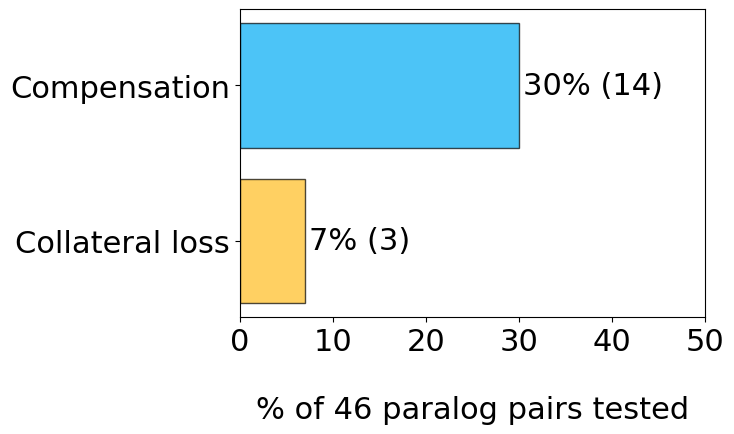

In [161]:
generate_comp_CL_barchart(HAP1_results, 'HAP1', colormap=coldict, xlim=50)

In [162]:
HAP1_prot_renamed = pd.read_csv('../output/output_HAP1/HAP1_prot_renamed.csv').set_index('gene_name')

data = {}

for pair in HAP1_results.gene_pair.to_list():
    splitlist = pair.split('_')
    A1 = splitlist[0]
    if len(splitlist) == 2:
        A2 = splitlist[1]
    elif len(splitlist) == 3:
        A2 = splitlist[1] + '_' + splitlist[2]
    genelist = [x for x in HAP1_prot_renamed.index.to_list() if ((f';{A1}' in x) or (f'{A1};' in x) or (x == A1))]
    if len(genelist)>0:
        gene_index = genelist[0]
    KO_samples = [x for x in HAP1_prot_renamed.columns.to_list() if A2 in x]
    KO_quants = HAP1_prot_renamed[(HAP1_prot_renamed.index == gene_index)][KO_samples].iloc[0].values.tolist()
    WT_quants = HAP1_prot_renamed[(HAP1_prot_renamed.index == gene_index)][[x for x in HAP1_prot_renamed.columns.to_list() if 'WT_' in x]].iloc[0].values.tolist()
    KO_quants = [x for x in KO_quants if np.isnan(x) == False]
    WT_quants = [x for x in WT_quants if np.isnan(x) == False]
    data[pair] = KO_quants, WT_quants


/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


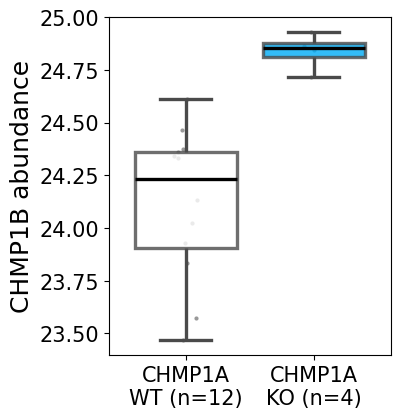

In [163]:
HAP1_boxplot('CHMP1B_CHMP1A', HAP1_results, data, coldict)

/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


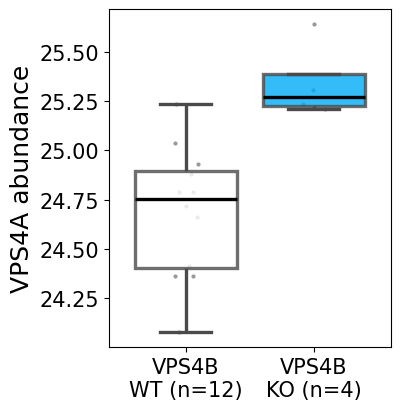

In [164]:
HAP1_boxplot('VPS4A_VPS4B', HAP1_results, data, coldict)

/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


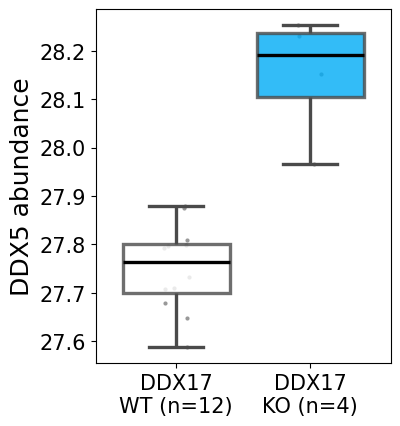

In [165]:
HAP1_boxplot('DDX5_DDX17', HAP1_results, data, coldict)

/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


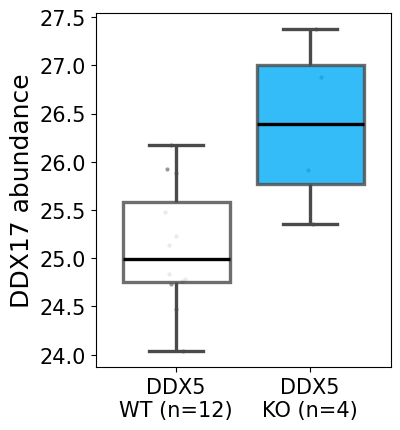

In [166]:
HAP1_boxplot('DDX17_DDX5', HAP1_results, data, coldict)


/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


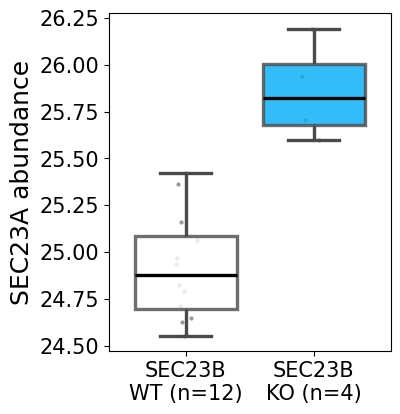

In [167]:
HAP1_boxplot('SEC23A_SEC23B', HAP1_results, data, coldict)


/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


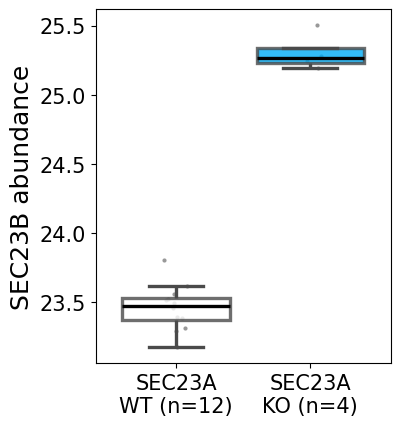

In [168]:
HAP1_boxplot('SEC23B_SEC23A', HAP1_results, data, coldict)


/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


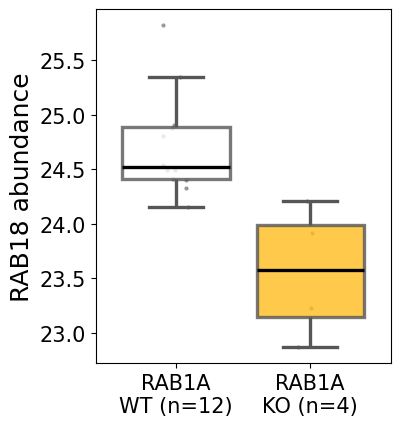

In [169]:
HAP1_boxplot('RAB18_RAB1A', HAP1_results, data, coldict)


/tmp/ipykernel_251061/4271381599.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Abundance', data=df, ax=ax,
/tmp/ipykernel_251061/4271381599.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nKO (n={ko_count})'], fontsize=13)


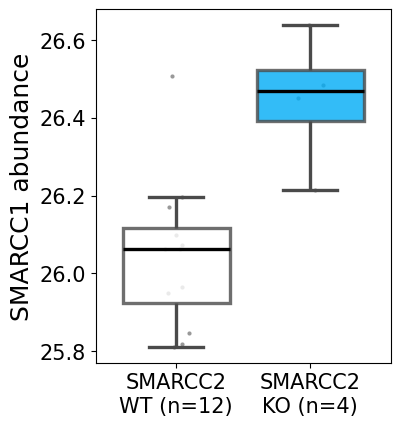

In [170]:
HAP1_boxplot('SMARCC1_SMARCC2', HAP1_results, data, coldict)


# CPTAC Figures

## Figure 2

In [171]:
prot_res = pd.read_csv('../output/output_CPTAC/prot/paralog_tests_prot.csv', index_col=0)
trans_res = pd.read_csv('../output/output_CPTAC/trans/paralog_tests_trans.csv', index_col=0)
resid_res = pd.read_csv('../output/output_CPTAC/prot_residual/paralog_tests_prot_residual.csv', index_col=0)
prot_res['gene_pair'] = prot_res['A1'] + '_' + prot_res['A2']
prot_res['sorted_gene_pair'] = prot_res['gene_pair'].apply(lambda x: '_'.join(sorted(x.split('_'))))
protcomp = prot_res[prot_res.compensation].gene_pair.to_list()
protcl = prot_res[prot_res.collateral_loss].gene_pair.to_list()
transcomp = trans_res[trans_res.compensation].gene_pair.to_list()
transcl = trans_res[trans_res.collateral_loss].gene_pair.to_list()
residcomp = resid_res[resid_res.compensation].gene_pair.to_list()
residcl = resid_res[resid_res.collateral_loss].gene_pair.to_list()

prot_res['category'] = prot_res.apply(lambda row: getcat(row['compensation'], row['collateral_loss']), axis=1)
trans_res['category'] = trans_res.apply(lambda row: getcat(row['compensation'], row['collateral_loss']), axis=1)
resid_res['category'] = resid_res.apply(lambda row: getcat(row['compensation'], row['collateral_loss']), axis=1)


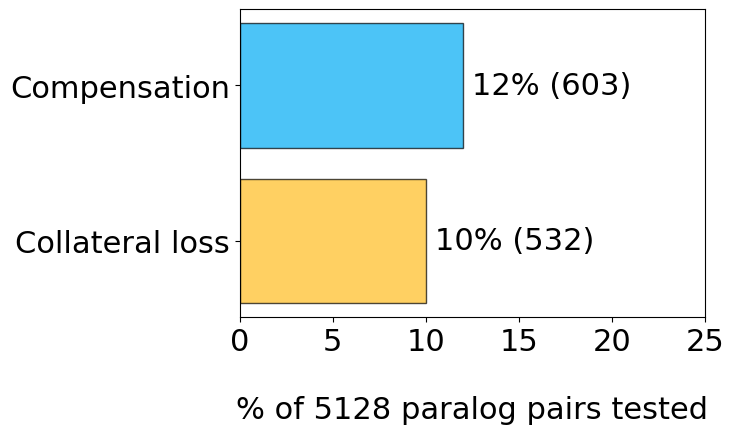

In [172]:
generate_comp_CL_barchart(prot_res, 'prot', colormap=coldict, xlim=25)

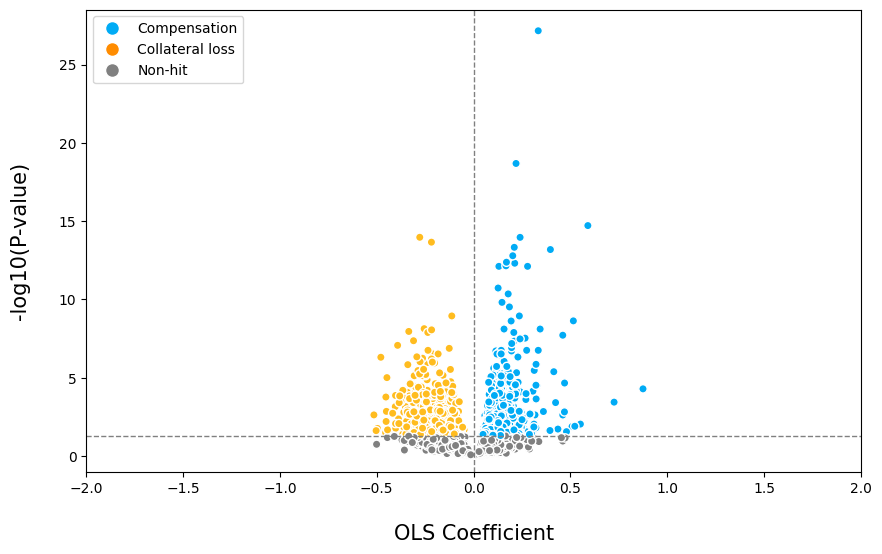

In [173]:
make_volcano_plot(prot_res, filename = 'prot', sigcutoff = 0.05, colordict = coldict)


In [174]:
# We use this for plotting to account for the fact that the model calling compensation and collateral loss
# has lineage/study and self-copy number as covariates

cptac_prot_minus_studycn = pd.read_csv('../data/CPTAC/prot_study_CN_resid.csv')
cptac_prot_minus_studycn = cptac_prot_minus_studycn.pivot(index='Sample', columns='Gene', values='Residuals')
cptac_prot_minus_studycn.index.name = 'sample_ID'
cptac_prot_minus_studycn.columns.name = ''
cptac_prot_minus_studycn[:2]

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADAT,...,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
sample_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,0.629684,NaN,0.496480,-0.727816,NaN,NaN,0.136395,-0.000409,NaN,0.797313,...,NaN,NaN,-0.152120,0.291223,-0.085828,1.233326,0.115637,0.186772,-0.707190,-0.090611
01BR008,-0.493148,NaN,0.026892,1.193296,NaN,NaN,0.163873,-0.847631,NaN,NaN,...,NaN,NaN,0.028238,0.390215,0.333120,0.926566,-0.158997,-0.273160,-0.035919,0.151976


In [175]:
A2_lost = pd.read_csv('../output/output_CPTAC/prot/A2_lost.csv').rename(columns = {'Unnamed: 0':'gene_name'}).set_index('gene_name')
A2_lost[:2]

/tmp/ipykernel_251061/3695951560.py:1: DtypeWarning: Columns (19,37,43,46,52,158,206,240,241,253,287,293,349,357,358,360,363,392,395,396,397,400,412,418,445,484,505,514,522,523,555,564,565,582,620,632,644,710,809,831,835,840,857,889,911) have mixed types. Specify dtype option on import or set low_memory=False.
  A2_lost = pd.read_csv('../output/output_CPTAC/prot/A2_lost.csv').rename(columns = {'Unnamed: 0':'gene_name'}).set_index('gene_name')


,01BR001,01BR008,01BR010,01BR015,01BR017,01BR018,01BR020,01BR023,01BR025,01BR026,...,C3N-04273,C3N-04275,C3N-04276,C3N-04277,C3N-04278,C3N-04279,C3N-04280,C3N-04282,C3N-04283,C3N-04611
gene_name,,,,,,,,,,,,,,,,,,,,,
POLR2B,NaN,False,False,False,False,False,False,NaN,False,False,...,True,False,False,False,True,False,False,False,False,False
APPL1,False,False,False,False,False,True,True,False,False,False,...,True,False,True,False,False,True,False,False,False,False


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


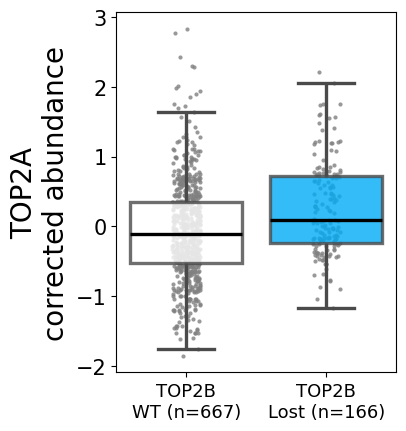

In [176]:
CPTAC_boxplot('TOP2A_TOP2B', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


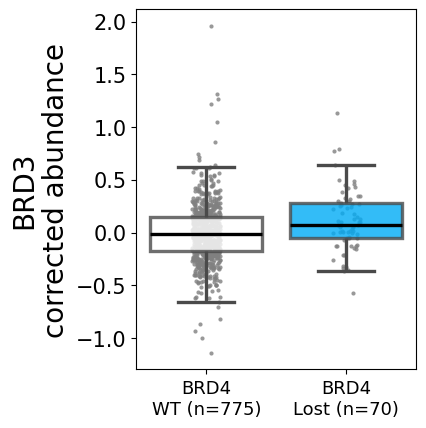

In [177]:
CPTAC_boxplot('BRD3_BRD4', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


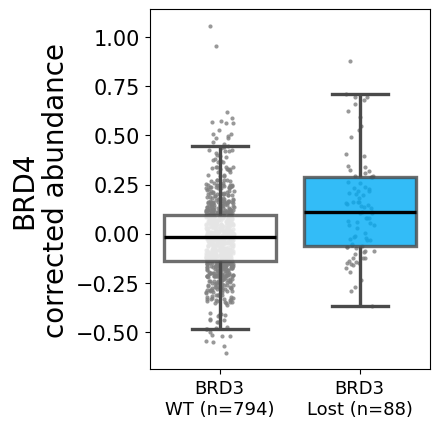

In [178]:
CPTAC_boxplot('BRD4_BRD3', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


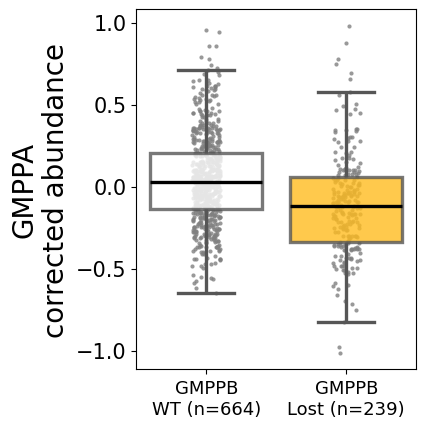

In [179]:
CPTAC_boxplot('GMPPA_GMPPB', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


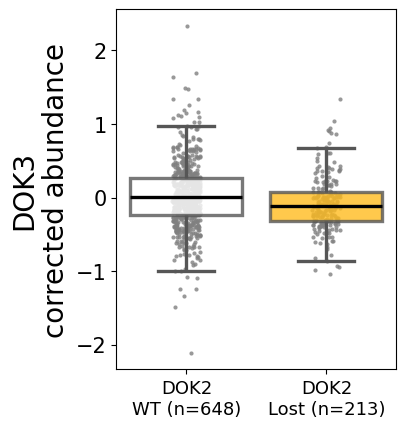

In [180]:
CPTAC_boxplot('DOK3_DOK2', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


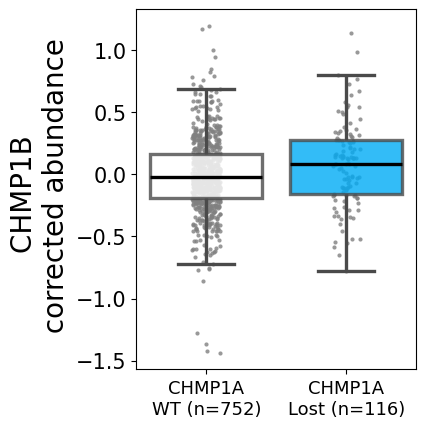

In [181]:
CPTAC_boxplot('CHMP1B_CHMP1A', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected abundance')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


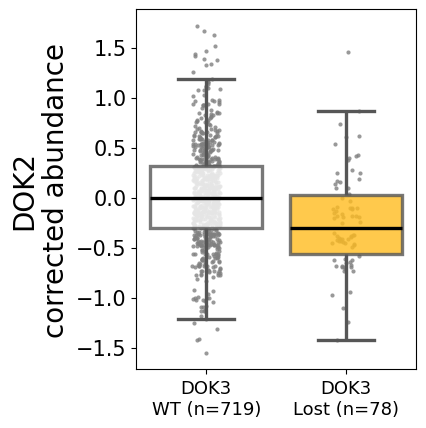

In [182]:
CPTAC_boxplot('DOK2_DOK3', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


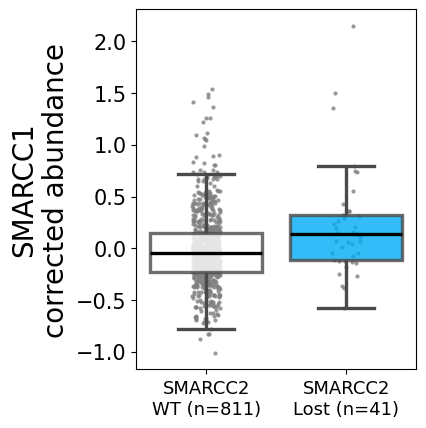

In [183]:
CPTAC_boxplot('SMARCC1_SMARCC2', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


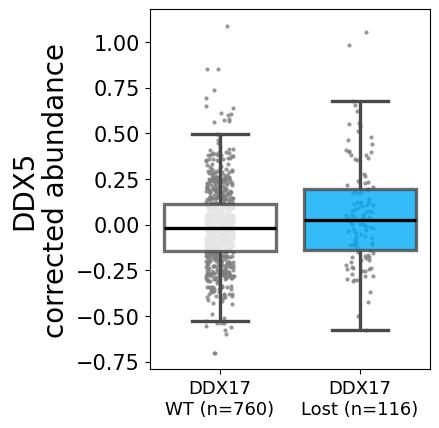

In [184]:
CPTAC_boxplot('DDX5_DDX17', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


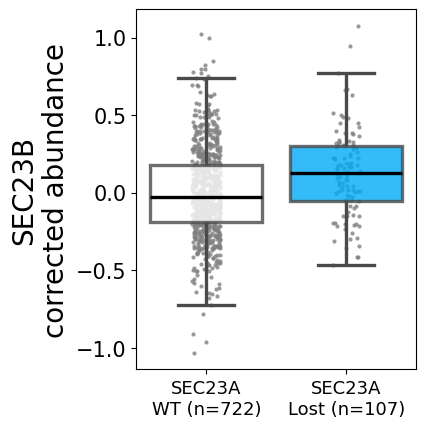

In [185]:
CPTAC_boxplot('SEC23B_SEC23A', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

## Figure 3

In [186]:
overlaps_prot = pd.read_csv('../output/output_CPTAC/prot/categorical_overlaps_prot.csv')
overlaps_trans = pd.read_csv('../output/output_CPTAC/trans/categorical_overlaps_trans.csv')
overlaps_resid = pd.read_csv('../output/output_CPTAC/prot_residual/categorical_overlaps_prot_residual.csv')

overlaps_prot['category'] = overlaps_prot.apply(lambda row: getcat(row['compensation'], row['collateral_loss']), axis=1)
overlaps_trans['category'] = overlaps_trans.apply(lambda row: getcat(row['compensation'], row['collateral_loss']), axis=1)
overlaps_resid['category'] = overlaps_resid.apply(lambda row: getcat(row['compensation'], row['collateral_loss']), axis=1)


In [187]:
annotated_res = pd.read_csv('../output/output_CPTAC/prot/all_quantoverlaps_prot.csv')

/tmp/ipykernel_251061/1981993307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = df2['category'].replace({'compensation': 'Compensation',
/tmp/ipykernel_251061/1981993307.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = pd.Categorical(df2['category'], categories=category_order, ordered=True)
/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

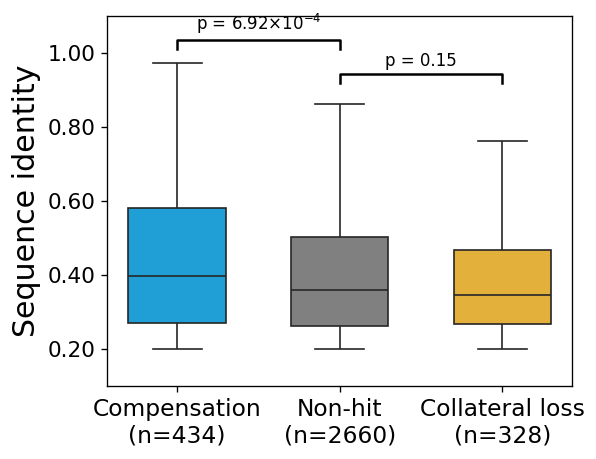

In [188]:
combined_ttest_and_boxplot('sequence_identity', annotated_res, 'seqid', ylim=True, coldict=coldict, namedict=namedict)


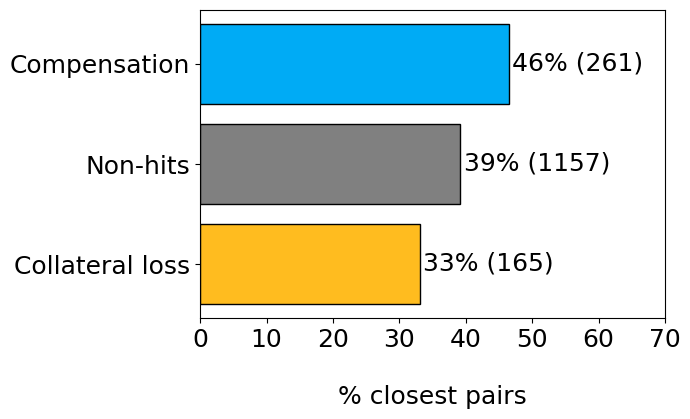

In [189]:
make_overlap_bar_chart(overlaps_prot, 'closest_pair', 70, '% closest pairs', colordictloc = coldict, filename = 'closestoverlap')


/tmp/ipykernel_251061/1981993307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = df2['category'].replace({'compensation': 'Compensation',
/tmp/ipykernel_251061/1981993307.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = pd.Categorical(df2['category'], categories=category_order, ordered=True)
/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

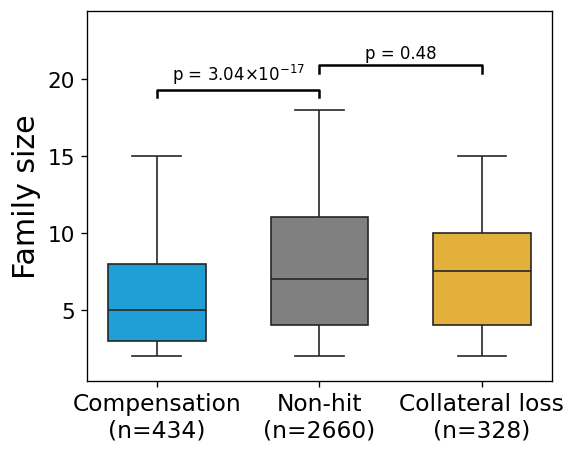

In [190]:
combined_ttest_and_boxplot('family_size', annotated_res, 'famsize', ylim=None, coldict=coldict, namedict=namedict)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


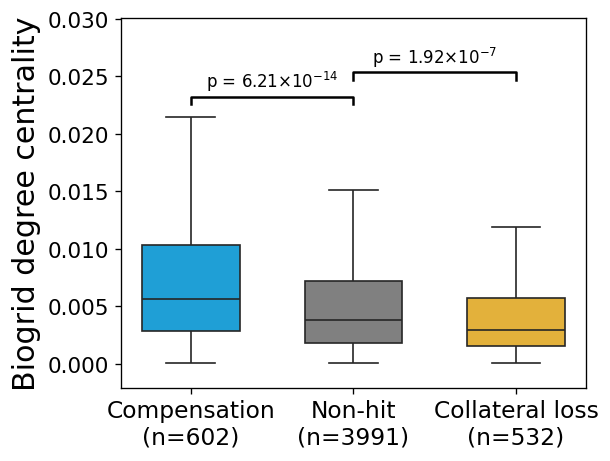

In [191]:
combined_ttest_and_boxplot('biogrid_dc', annotated_res, 'biogrid_dc', coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = df2['category'].replace({'compensation': 'Compensation',
/tmp/ipykernel_251061/1981993307.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = pd.Categorical(df2['category'], categories=category_order, ordered=True)
/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

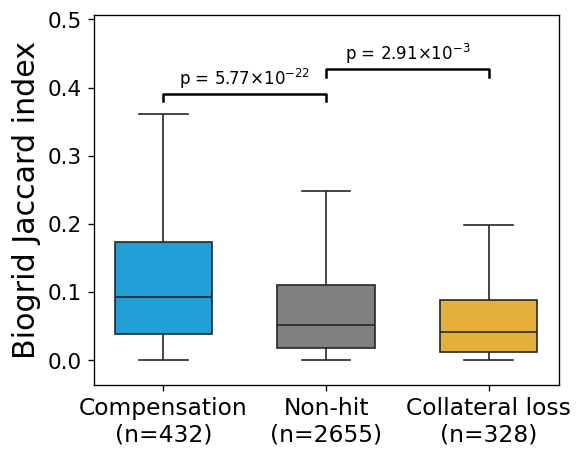

In [192]:
combined_ttest_and_boxplot('bg_jaccard', annotated_res, 'bg_jaccard', ylim=None, coldict=coldict, namedict=namedict)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


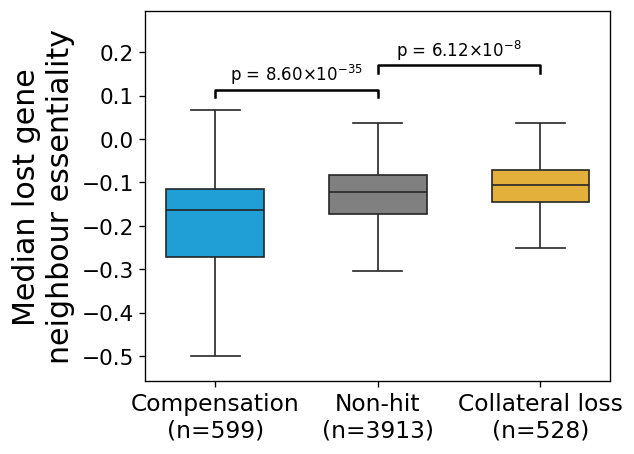

In [193]:
combined_ttest_and_boxplot('A2_median_neighbour_ess', annotated_res, 'A2_median_neighbour_ess', ylim=None, coldict=coldict, namedict=namedict, drop=False)


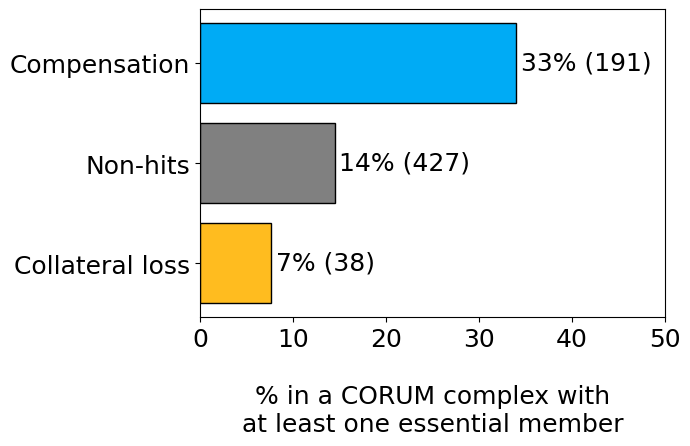

In [194]:
make_overlap_bar_chart(overlaps_prot, 'in_PC_CORUM_essential', 50, '% in a CORUM complex with\nat least one essential member', colordictloc = coldict, filename = 'CORUM_ess_overlap')


### Figure 4: Plots made in logistic regression notebook

## Figure 5

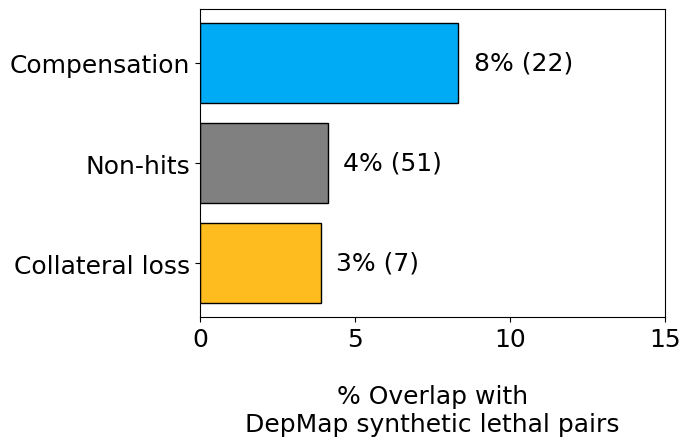

In [195]:
make_overlap_bar_chart(overlaps_prot, 'bronze_standard_SL', 15, '% Overlap with\nDepMap synthetic lethal pairs', colordictloc = coldict, filename = 'depmapoverlap')


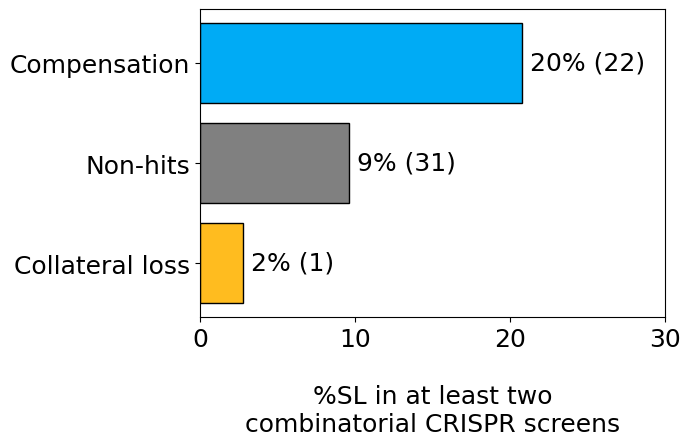

In [196]:
make_overlap_bar_chart(overlaps_prot, 'strict_comb_hit', 30, '%SL in at least two\ncombinatorial CRISPR screens', colordictloc = coldict, filename = 'strict_comb_overlap')


In [197]:
# De Kegel et al 2021 results, processed to add sorted_gene_pair and gene_pair

CRISPR_results = pd.read_csv('../data/for_overlap/CRISPR_SL_processed.csv').drop(columns = 'Unnamed: 0')
CRISPR_results[:2]

,sorted_gene_pair,A1,A2,A2_status_coef,A2_status_p,A2_status_p_adj,SL,A1_entrez,A2_entrez,A1_ensembl,A2_ensembl,gene_pair
0,AAK1_BMP2K,AAK1,BMP2K,-0.033329,0.445594,0.873493,False,22848,55589,ENSG00000115977,ENSG00000138756,AAK1_BMP2K
1,AAK1_BMP2K,BMP2K,AAK1,-0.059093,0.083675,NaN,False,55589,22848,ENSG00000138756,ENSG00000115977,BMP2K_AAK1


In [198]:
# Downloaded from HUGO Gene Nomenclature portal

mapping = pd.read_csv('../data/general/geneidmap_sep24.txt', sep = '\t').rename(columns = {'Approved symbol':'gene_name','NCBI Gene ID(supplied by NCBI)':'entrez_id'})
mapping = mapping.dropna()
mapping['entrez_id'] = mapping['entrez_id'].astype(int)
mapping['entrez_id'] = mapping['entrez_id'].astype(str)
mapping.set_index('entrez_id', inplace = True)
mapping.index = mapping.index.astype(str)
def get_gene_name(entid):
    if entid in mapping.index:
        return mapping.loc[entid, 'gene_name']
    else:
        return np.nan
mapping[:2]

,gene_name,Ensembl ID(supplied by Ensembl),UniProt ID(supplied by UniProt)
entrez_id,,,
1,A1BG,ENSG00000121410,P04217
29974,A1CF,ENSG00000148584,Q9NQ94


In [199]:
# These annotations of which cell lines have lost genes in DepMap is obtained from running the analysis outlined in De Kegel et al 2021
# Loss is called based on the presence of a homozygous deletion (called using absolute copy number), mRNA expression below 1 log TPM,
# z-scored mRNA expression below -4, or the presence of a loss-of-function mutation

essentiality_lost = pd.read_csv('../data/for_overlap/A2_lost_essentiality.csv').rename(columns = {'Unnamed: 0':'gene_name'}).set_index('gene_name')
essentiality_lost.index =essentiality_lost.index.astype(str)
essentiality_lost = essentiality_lost.reset_index()
essentiality_lost['gene_name'] = essentiality_lost['gene_name'].apply(get_gene_name)
essentiality_lost.dropna(subset = 'gene_name',inplace = True)
essentiality_lost =essentiality_lost.set_index('gene_name')
essentiality_lost.index = essentiality_lost.index.astype(str)
essentiality_lost[:2]

,ACH-000004,ACH-000005,ACH-000007,ACH-000009,ACH-000011,ACH-000012,ACH-000013,ACH-000014,ACH-000015,ACH-000017,...,ACH-001960,ACH-001997,ACH-001999,ACH-002001,ACH-002002,ACH-002003,ACH-002004,ACH-002005,ACH-002015,ACH-002016
gene_name,,,,,,,,,,,,,,,,,,,,,
POLR2B,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
APPL1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [200]:
# CERES scores reprocessed as outlined in De Kegel et al 2021
scores_filtered = pd.read_csv('../data/for_overlap/scores_depmap.csv').set_index('cell_line')
scores_filtered.columns = scores_filtered.columns.map(lambda x: get_gene_name(x))
scores_filtered.columns = scores_filtered.columns.astype(str)
scores_filtered[:2]

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
cell_line,,,,,,,,,,,,,,,,,,,,,
ACH-001382,0.652347,-0.020793,-0.270112,-0.211408,0.06271,-0.081674,0.376840,-0.767385,0.166991,0.112045,...,0.182055,-0.724872,0.499652,-0.141164,-0.336501,0.250665,-0.676302,-0.098001,-0.677497,-0.506629
ACH-000250,-0.081394,0.093385,0.005231,0.158573,0.01236,-0.047724,0.133516,-0.478856,0.018642,0.085868,...,0.003926,-0.068262,-0.005768,-0.241775,0.000087,0.085940,-0.104364,-0.040344,-0.057078,-0.180227


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


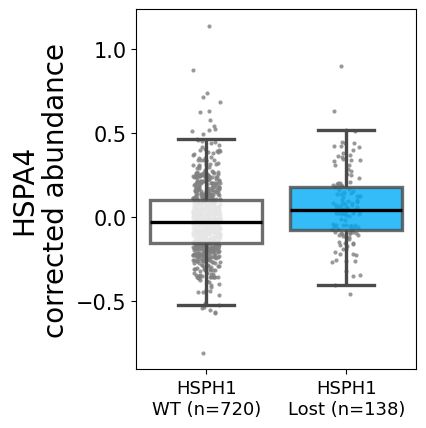

In [201]:
CPTAC_boxplot('HSPA4_HSPH1', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


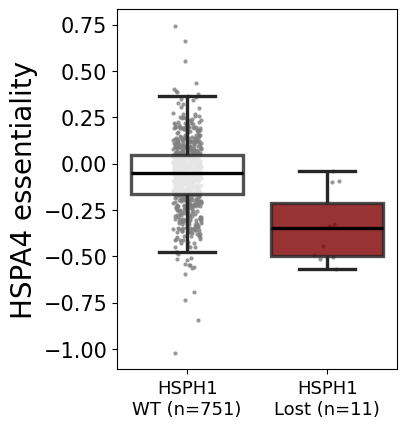

In [202]:
CPTAC_boxplot('HSPA4_HSPH1', CRISPR_results, scores_filtered, essentiality_lost, coldict, 'essentiality', ess=True)

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


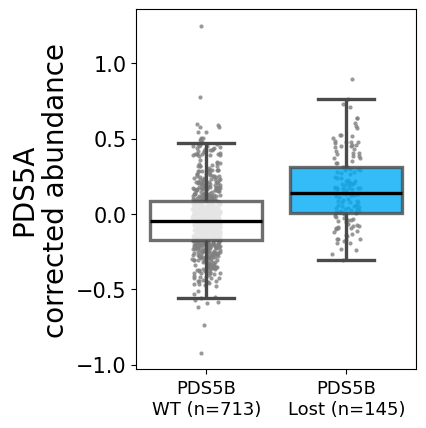

In [203]:
CPTAC_boxplot('PDS5A_PDS5B', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


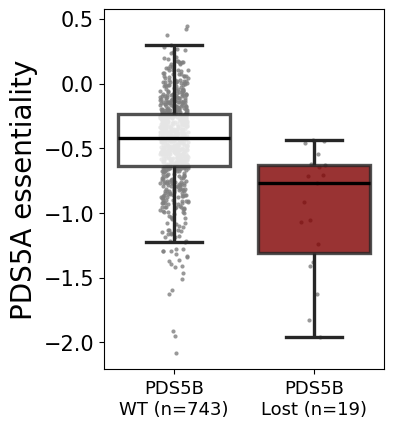

In [204]:
CPTAC_boxplot('PDS5A_PDS5B', CRISPR_results, scores_filtered, essentiality_lost, coldict, 'essentiality', ess=True)

### Subplots e and f made in logistic regression notebook

## Figure 6

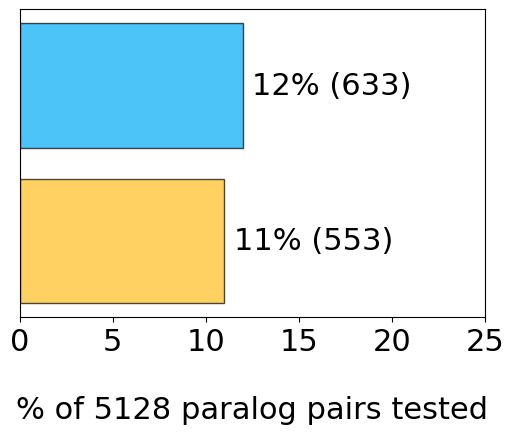

In [205]:
generate_comp_CL_barchart(trans_res, 'trans', colormap=coldict, xlim=25, yticks=False)


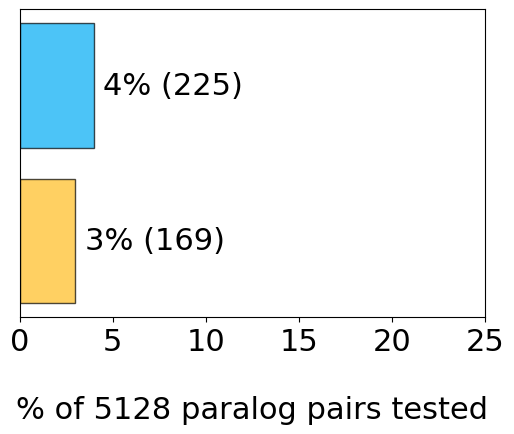

In [206]:
generate_comp_CL_barchart(resid_res, 'resid', colormap=coldict, xlim=25, yticks=False)


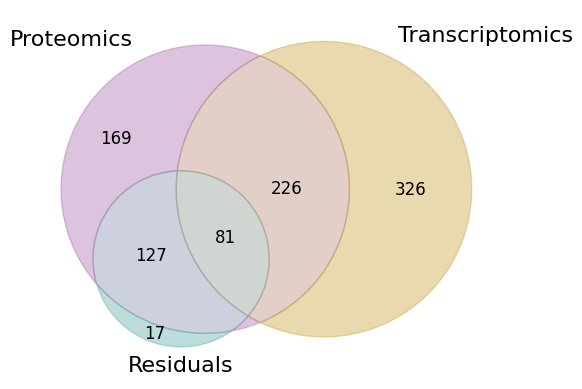

In [207]:
draw_venn(protcomp, transcomp, residcomp, 'comp')


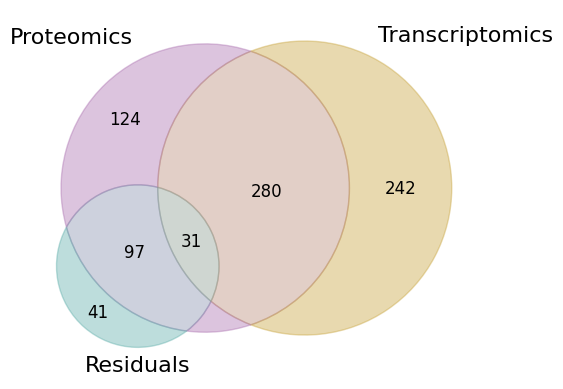

In [208]:
draw_venn(protcl, transcl, residcl, 'cl')

In [209]:
# More overlap than expected by chance? 

def perform_fet(tested_pairs, mrna_hits, protein_hits):
    tested_pairs_set = set(tested_pairs)
    mrna_hits_set = set(mrna_hits) & tested_pairs_set
    protein_hits_set = set(protein_hits) & tested_pairs_set
    hit_counts = Counter({
        'both': len(mrna_hits_set & protein_hits_set),
        'mrna_only': len(mrna_hits_set - protein_hits_set),
        'protein_only': len(protein_hits_set - mrna_hits_set),
        'neither': len(tested_pairs_set - mrna_hits_set - protein_hits_set)})

    contingency_table = np.array([
        [hit_counts['both'], hit_counts['protein_only']],
        [hit_counts['mrna_only'], hit_counts['neither']]])

    odds_ratio, p_value = fisher_exact(contingency_table)
    return odds_ratio, p_value

odds_ratio_comp, p_value_comp = perform_fet(prot_res.gene_pair.to_list(), transcomp, protcomp)
print('Compensation: ')
print(f"Odds Ratio: {odds_ratio_comp}")
print(f"P-value: {p_value_comp}")

odds_ratio_cl, p_value_cl = perform_fet(prot_res.gene_pair.to_list(), transcl, protcl)
print('\nCollateral loss: ')
print(f"Odds Ratio: {odds_ratio_cl}")
print(f"P-value: {p_value_cl}")


Compensation: 
Odds Ratio: 13.359030426131653
P-value: 4.219111428444322e-144

Collateral loss: 
Odds Ratio: 25.31868666093265
P-value: 4.4932259690194825e-195


In [210]:
cptac_trans_minus_studycn = pd.read_csv('../data/CPTAC/trans_study_CN_resid.csv')
cptac_trans_minus_studycn = cptac_trans_minus_studycn.pivot(index='Sample', columns='Gene', values='Residuals')
cptac_trans_minus_studycn.index.name = 'sample_ID'
cptac_trans_minus_studycn.columns.name = ''
cptac_trans_minus_studycn[:2]

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADAT,...,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
sample_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,0.259596,-1.703801,-0.618369,0.437516,0.631434,-1.685448,-0.523951,0.078711,-0.737345,0.394205,...,-0.480171,0.058588,0.043056,-0.416663,-1.606906,-0.158185,-0.02671,-0.172086,-0.436222,-0.798603
01BR008,-0.350404,1.226899,-0.356683,4.898741,-1.020466,-0.003648,0.326549,-0.740146,-2.180945,1.629793,...,-0.071471,0.157488,0.062756,0.549814,1.555794,-0.108685,-1.35901,0.648414,-0.186122,-0.298303


In [211]:
cptac_resid = pd.read_csv('../data/CPTAC/CPTAC_prot_residuals.csv')
cptac_resid = cptac_resid[['gene_in_sample', 'Residuals']]
cptac_resid[['gene', 'sample']] = cptac_resid['gene_in_sample'].str.split('_in_', n=1, expand=True)
cptac_resid = cptac_resid.pivot(index='sample', columns='gene', values='Residuals')
cptac_resid.index.name = 'sample_ID'
cptac_resid.columns.name = ''
cptac_resid[:2]

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADAT,...,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
sample_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,0.625387,NaN,0.608315,-0.852226,NaN,NaN,0.191040,0.003923,NaN,0.735036,...,NaN,NaN,-0.163533,0.609336,0.539669,1.268501,0.128450,0.227388,-0.589731,0.017713
01BR008,-0.482531,NaN,0.084366,-0.379444,NaN,NaN,0.126785,-0.371684,NaN,NaN,...,NaN,NaN,0.012110,0.086561,-0.258000,0.945699,0.145815,-0.426403,0.039320,0.196012


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


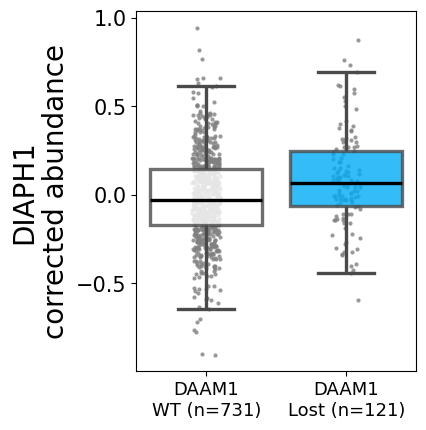

In [212]:
CPTAC_boxplot('DIAPH1_DAAM1', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein', suffix = 'prot')


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


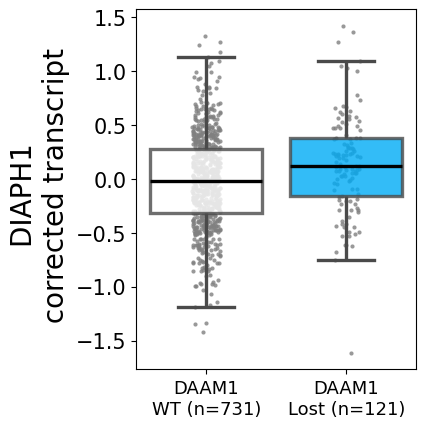

In [213]:
CPTAC_boxplot('DIAPH1_DAAM1', trans_res, cptac_trans_minus_studycn, A2_lost, coldict, '\n corrected transcript' , suffix = 'trans')


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


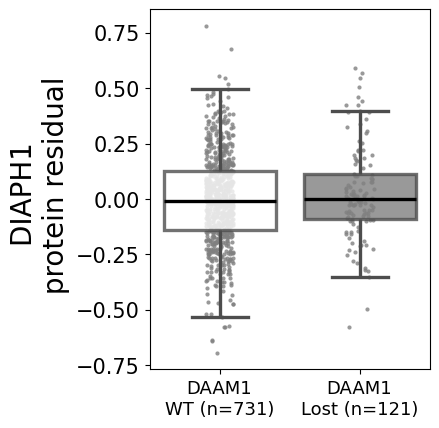

In [214]:
CPTAC_boxplot('DIAPH1_DAAM1', resid_res, cptac_resid, A2_lost, coldict, '\n protein residual', suffix = 'res')


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


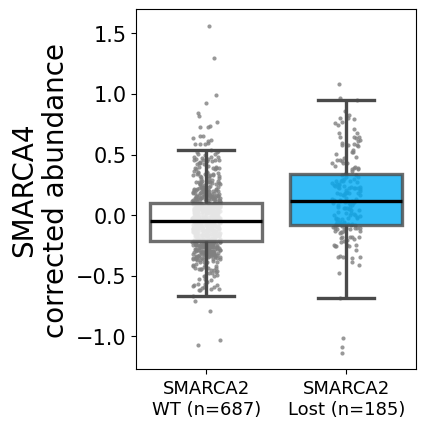

In [215]:
CPTAC_boxplot('SMARCA4_SMARCA2', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, '\n corrected protein', suffix = 'prot')


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


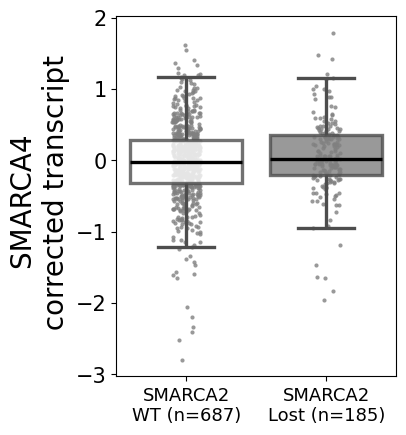

In [216]:
CPTAC_boxplot('SMARCA4_SMARCA2', trans_res, cptac_trans_minus_studycn, A2_lost, coldict, '\n corrected transcript', suffix = 'trans')


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


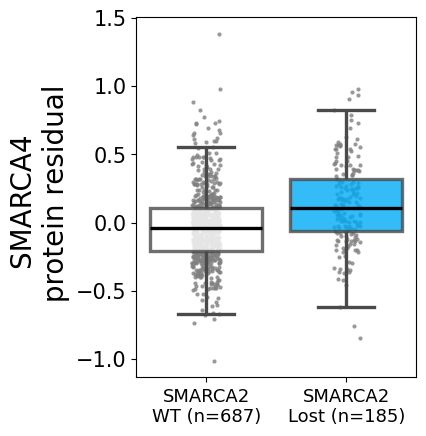

In [217]:
CPTAC_boxplot('SMARCA4_SMARCA2', resid_res, cptac_resid, A2_lost, coldict, '\n protein residual', suffix = 'resid')


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


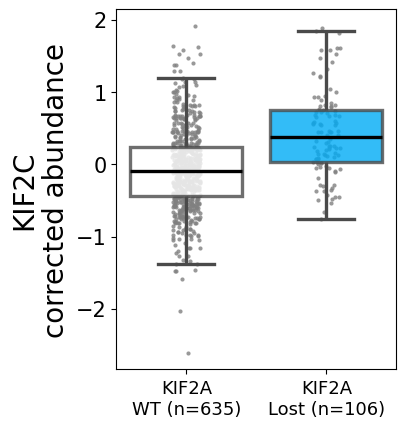

In [218]:
CPTAC_boxplot('KIF2C_KIF2A', prot_res, cptac_prot_minus_studycn, A2_lost, coldict, 'corrected protein', suffix = 'prot')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


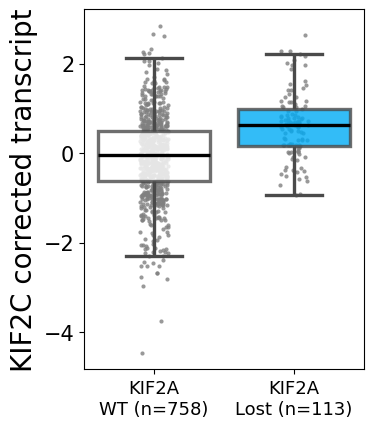

In [219]:
CPTAC_boxplot('KIF2C_KIF2A', trans_res, cptac_trans_minus_studycn, A2_lost, coldict, 'corrected transcript', suffix = 'trans')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


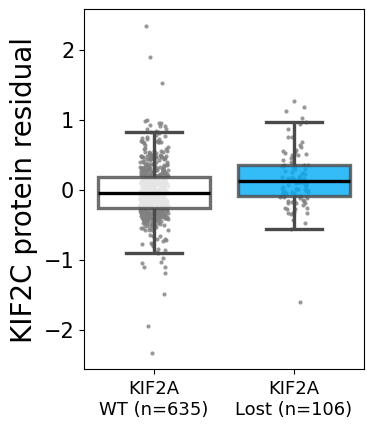

In [220]:
CPTAC_boxplot('KIF2C_KIF2A', resid_res, cptac_resid, A2_lost, coldict, 'protein residual', suffix = 'resid')

In [221]:
fish_prot_sorted = pd.read_csv('../output/output_CPTAC/prot/categorical_FETs_uniquegenepairs_prot.csv')
fish_trans_sorted = pd.read_csv('../output/output_CPTAC/trans/categorical_FETs_uniquegenepairs_trans.csv')
fish_res_sorted = pd.read_csv('../output/output_CPTAC/prot_residual/categorical_FETs_uniquegenepairs_prot_residual.csv')


In [222]:
ydict = {'in_PC_CORUM_both':'Both in same CORUM complex', 'strict_comb_hit':'Synthetic lethal in at least 2 CRISPR screens','in_PC_humap':'Either member in Humap complex','bronze_standard_SL':'DepMap synthetic lethal','lenient_comb_hit':'Synthetic lethal in at least one CRISPR screen', 'in_PC_EBI':'Either member in EBI ComplexPortal complex','in_PC_CORUM':'Either member in CORUM complex', 'famsize2':'Family size 2','interacting_pair':'Physically interacting', 'closest_pair':'Closest pair', 'WGD':'Whole genome duplicates', 'other_dir_comp':'Reciprocal compensation hit', 'other_dir_cl':'Reciprocal collateral loss hit', 'A1_never_ess': 'Compensating gene never essential', 'A2_never_ess':'Lost gene never essential', 'A1_sometimes_ess':'Compensating gene sometimes essential', 'A2_sometimes_ess':'Lost gene sometimes essential', 'A1_broadly_ess':'Compensating gene broadly essential', 'A2_broadly_ess':'Lost gene broadly essential', 'in_PC_CORUM_essential':'Either member in essential CORUM complex', 'direct_interaction':'Paralogs physically interact', 'coreg_tf':'Coregulated by same transcription factor'}


/tmp/ipykernel_251061/3636089769.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sig'] = (df['FET_p'] < 0.05) & (df['FET_p_adj'] < FDR)
/tmp/ipykernel_251061/3636089769.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['index'] = df['interaction_dataset'] + '_' + df['hit_type']
/tmp/ipykernel_251061/3636089769.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

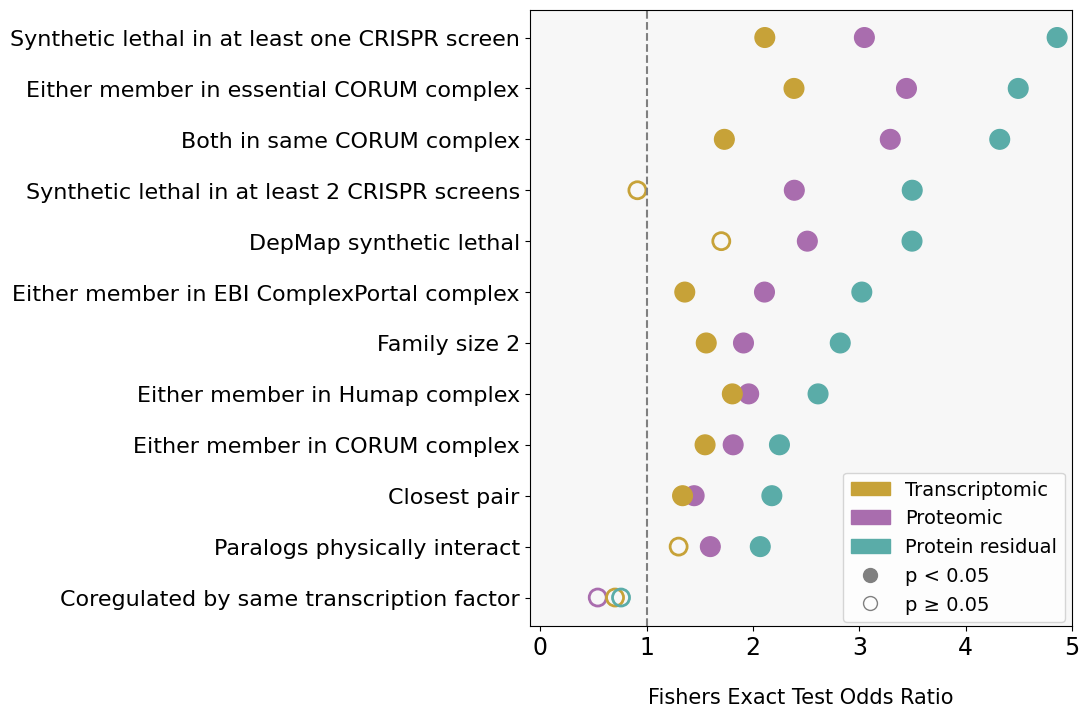

In [223]:
plot_OR('compensation', 0.05, fish_prot_sorted, df2=fish_trans_sorted,df3=fish_res_sorted, 
                    df1_label='Proteomic', df2_label='Transcriptomic', df3_label ='Protein residual', 
                    displaydf=False, ylabel_dict = ydict, rightxlim=5)


In [224]:
ub_sites = pd.read_csv('../data/for_overlap/Ubiquitination_site_dataset', sep='\t')
ub_sites = ub_sites.dropna(subset='GENE')
ub_sites.GENE = ub_sites.GENE.astype(str).apply(lambda x: x.upper())
ubdict = ub_sites.GENE.value_counts().to_dict()
ub_sites[:2]

/tmp/ipykernel_251061/3486706209.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  ub_sites = pd.read_csv('../data/for_overlap/Ubiquitination_site_dataset', sep='\t')


,GENE,PROTEIN,ACC_ID,HU_CHR_LOC,MOD_RSD,SITE_GRP_ID,ORGANISM,MW_kD,DOMAIN,SITE_+/-7_AA,LT_LIT,MS_LIT,MS_CST,CST_CAT#,Ambiguous_Site
0,YWHAB,14-3-3 beta,P31946,20q13.12,K5-ub,41481400,human,28.08,NaN,___MtMDksELVQkA,NaN,4.0,NaN,NaN,0
1,YWHAB,14-3-3 beta,P31946,20q13.12,K11-ub,4953847,human,28.08,14-3-3,DksELVQkAkLAEQA,NaN,7.0,26.0,NaN,0


In [225]:
all_corum = pd.read_csv('../data/for_overlap/corum_with_symbols_nov23.csv', index_col = 0)
all_corum[:2]

,gene_symbol,complex
0,ABCF2,SNW1 complex
1,MATR3,p54(nrb)-PSF-matrin3 complex


In [226]:
prot_tested = prot_res.gene_pair.to_list()
all_comp_union = list(np.union1d(np.union1d(protcomp, transcomp), residcomp))
all_cl_union = list(np.union1d(np.union1d(protcl, transcl), residcl))
all_hits_union = list(np.union1d(all_comp_union, all_cl_union))
never_hits = np.setdiff1d(prot_tested, all_hits_union)


all_corum_prots = list(set(all_corum.gene_symbol.to_list()))
all_tested_A1s = prot_res.A1.to_list()
all_corum_prots = [x for x in all_corum_prots if x in all_tested_A1s]

complex_sizes = get_complex_sizes(all_corum_prots, all_corum)
big_complex_prots = list({k:v for k,v in complex_sizes.items() if v > 10}.keys())
not_corum_prots = list(np.setdiff1d(prot_res.A1.to_list(), all_corum_prots))
all_post_trans_A1s = list(set(resid_res[resid_res.compensation].A1.to_list()))
all_trans_A1s = list(prot_res[prot_res.gene_pair.isin(list(np.setdiff1d(trans_res[trans_res.compensation].gene_pair, prot_res[prot_res.compensation].gene_pair)))].A1.unique())
all_non_hit_A1s = list(prot_res[prot_res.gene_pair.isin(never_hits)].A1.unique())



In [227]:
ubsite_df = create_ubsite_df(not_corum_prots, all_corum_prots, big_complex_prots, all_post_trans_A1s, all_trans_A1s, all_non_hit_A1s, ubdict)
ubsite_df[:2]

,Protein,Category,num_ub_sites
0,A2ML1,Not\nin CORUM,0
1,AAK1,Not\nin CORUM,5


In [228]:
category_order = ['CORUM\ncomplex\nsize >10', 'In\nCORUM', 'Post-trans\ncomp', 'Trans\nexclusive\ncomp','Never\nhits', 'Not\nin CORUM']

ub_color_dict = {
    'CORUM\ncomplex\nsize >10': 'white',
    'In\nCORUM': 'white',
    'Post-trans\ncomp': '#5AACA8',
    'Trans\nexclusive\ncomp': '#C7A238',
    'Never\nhits': '#999999ff',
    'Not\nin CORUM': 'white'
}


/tmp/ipykernel_251061/2476909863.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Category', y='num_ub_sites', data=ubsite_df,
/tmp/ipykernel_251061/2476909863.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels_with_sizes, rotation=0, ha='center')


Comparison: CORUM complex size >10 vs In CORUM
Median CORUM complex size >10: 14.0
Median In CORUM: 10.0
Sample size: n=193 and n=471
Mann-Whitney U statistic: 53576.5
P-value: 2.92×10^-4
Effect size (Cliff's Delta): 0.179
Interpretation: small effect (higher)

Comparison: In CORUM vs Post-trans comp
Median In CORUM: 10.0
Median Post-trans comp: 12.0
Sample size: n=471 and n=204
Mann-Whitney U statistic: 41950.5
P-value: 8.80×10^-3
Effect size (Cliff's Delta): -0.127
Interpretation: negligible effect (lower)

Comparison: Post-trans comp vs Trans exclusive comp
Median Post-trans comp: 12.0
Median Trans exclusive comp: 8.0
Sample size: n=204 and n=272
Mann-Whitney U statistic: 34528.0
P-value: 4.85×10^-6
Effect size (Cliff's Delta): 0.245
Interpretation: small effect (higher)

Comparison: Trans exclusive comp vs Never hits
Median Trans exclusive comp: 8.0
Median Never hits: 7.0
Sample size: n=272 and n=2180
Mann-Whitney U statistic: 315297.5
P-value: 0.0870
Effect size (Cliff's Delta): 0

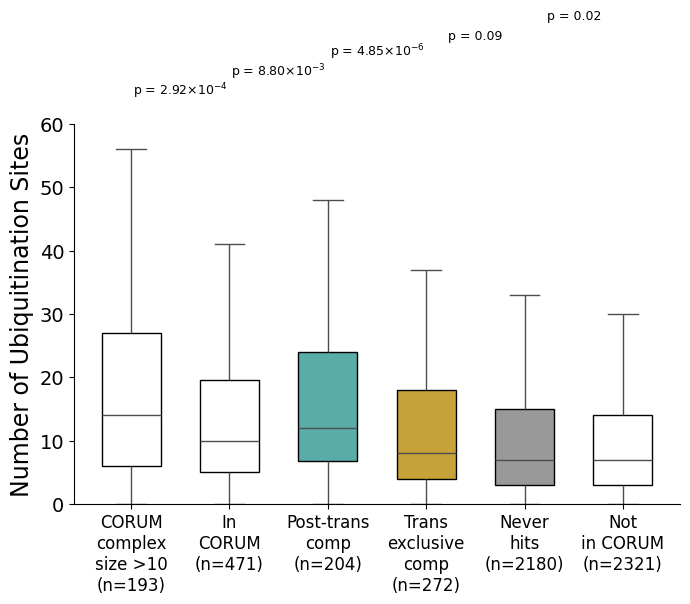

In [229]:

plot_ubiquitination_sites(ubsite_df, category_order, color_dict=ub_color_dict, add_p_values=True, save=True)

### Figure 7 created in Inkscape

## Figure EV1

In [230]:
results_A2 = pd.read_csv('../output/output_CPTAC/prot/self_tests_prot.csv')

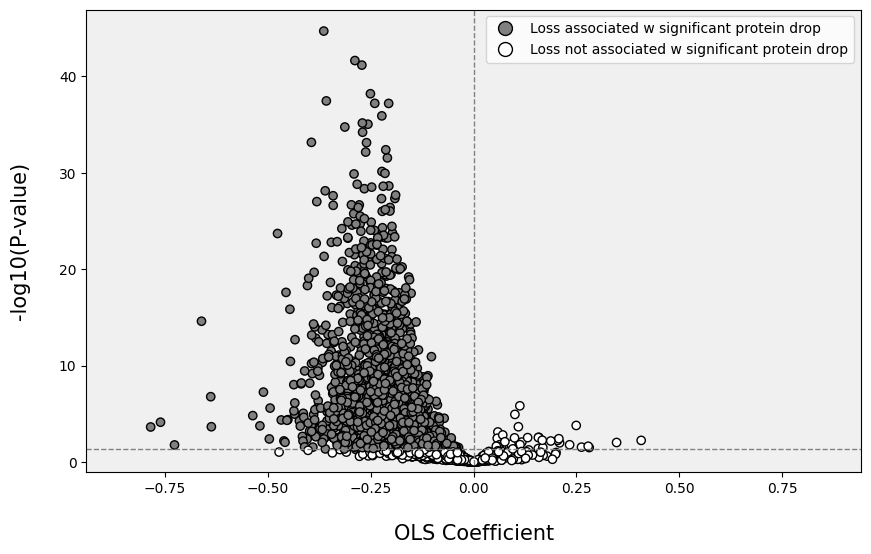

In [231]:
make_volcano_plot(results_A2, 'prot', 0.05, colordict=coldict, xlim=False, A2=True)


In [232]:
# We only correct for study when doing the self-tests, so we have a separate set of residuals for these plots

prot_minus_study_only = pd.read_csv('../data/CPTAC/prot_study_resid.csv')
prot_minus_study_only = prot_minus_study_only.pivot(index='Sample', columns='Gene', values='Residuals')
prot_minus_study_only.index.name = 'sample_ID'
prot_minus_study_only.columns.name = ''
prot_minus_study_only[:2]

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADAT,...,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
sample_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,0.631365,NaN,0.497650,-0.744488,NaN,NaN,0.137513,-0.170032,NaN,0.946434,...,NaN,NaN,-0.118403,0.223218,-0.085294,1.194652,0.132908,0.180199,-0.638268,-0.081942
01BR008,-0.491467,NaN,0.006215,1.643444,NaN,NaN,0.164991,-0.842962,NaN,NaN,...,NaN,NaN,0.061955,0.404109,0.333653,0.887891,-0.141726,-0.279733,0.033003,0.160646


In [233]:
# Makes life easier, none of these args change across plots except gene

def make_A2A2plot(gene, res = prot_res, prot = prot_minus_study_only, lost = A2_lost, cols = coldict):
    CPTAC_boxplot(f'{gene}_{gene}', res, prot, lost, cols, 'protein', plottingA2= True)


/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


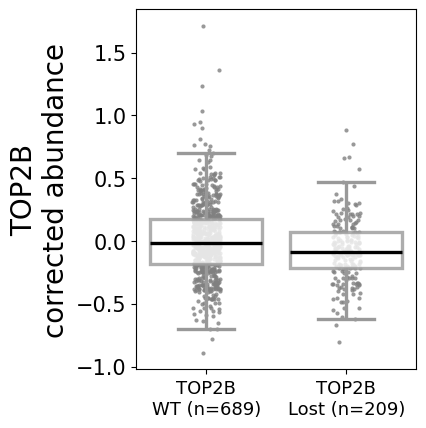

In [234]:
make_A2A2plot('TOP2B')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


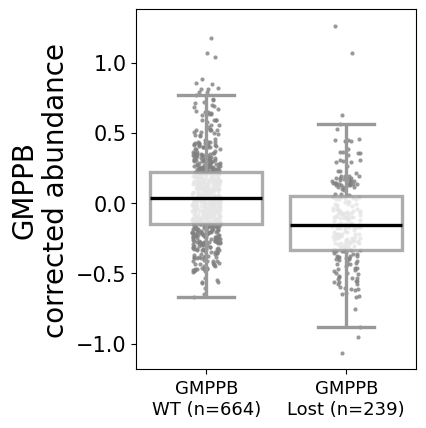

In [235]:
make_A2A2plot('GMPPB')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


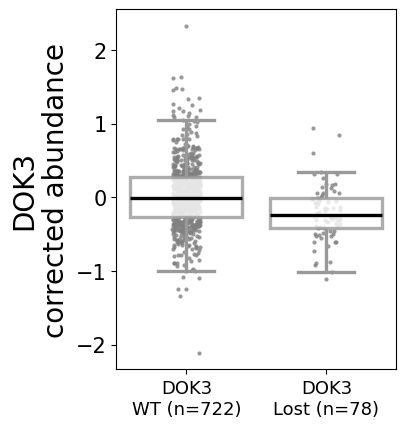

In [236]:
make_A2A2plot('DOK3')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


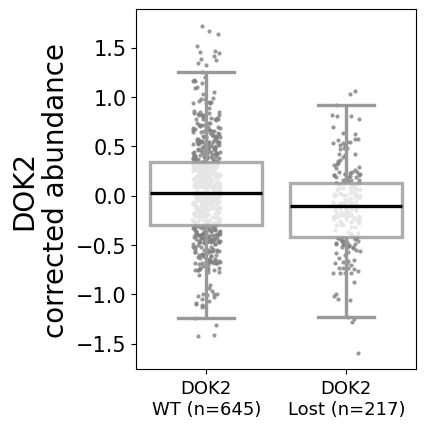

In [237]:
make_A2A2plot('DOK2')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


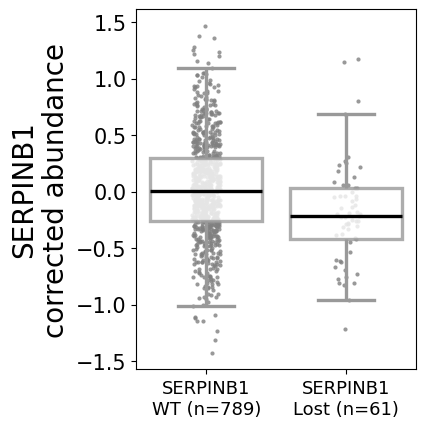

In [238]:
make_A2A2plot('SERPINB1')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


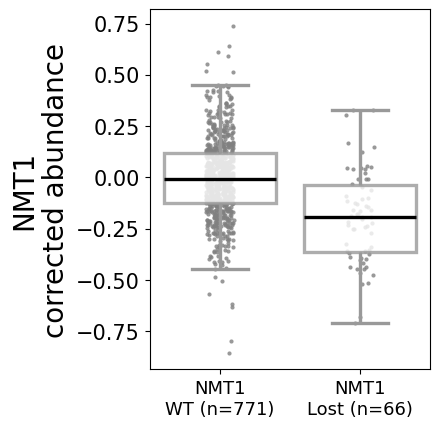

In [239]:
make_A2A2plot('NMT1')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


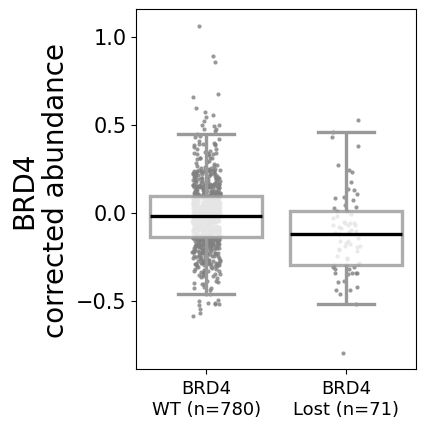

In [240]:
make_A2A2plot('BRD4')

/tmp/ipykernel_251061/2643843122.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=f'A1_{measure}', x='A2_lost', data=df, ax=ax,
/tmp/ipykernel_251061/2643843122.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{A2}\nWT (n={wt_count})', f'{A2}\nLost (n={lost_count})'], fontsize=13)


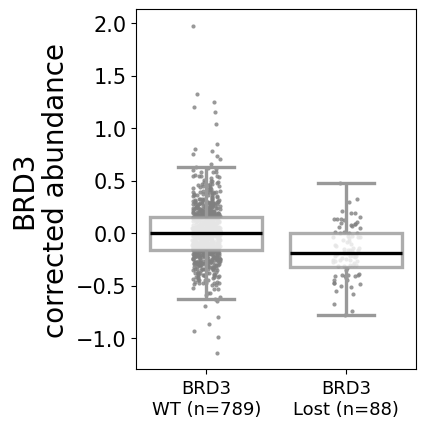

In [241]:
make_A2A2plot('BRD3')

### Figure EV2 created in Inkscape- check output dir for relevant numbers (pairs_filtered_at_each_step)

### Figure EV3: Boxplots generated earlier

## Figure EV4

/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


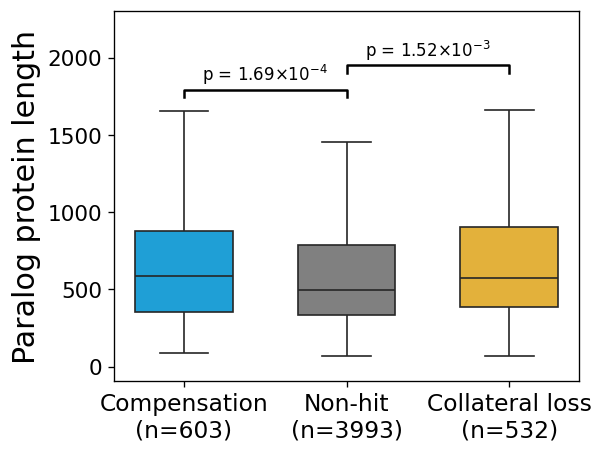

In [242]:
combined_ttest_and_boxplot('A1_length', annotated_res, 'A1_len', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


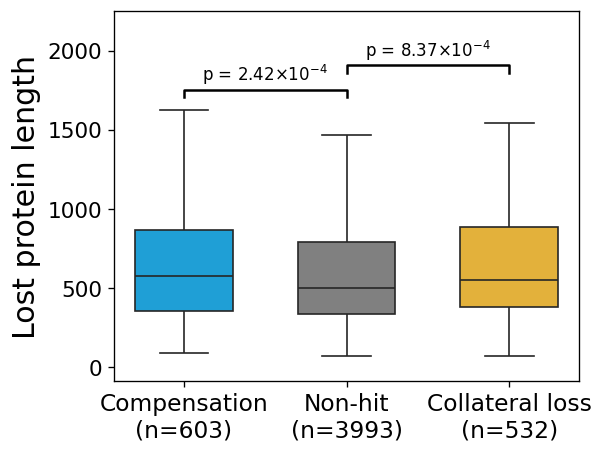

In [243]:
combined_ttest_and_boxplot('A2_length', annotated_res, 'A2_len', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


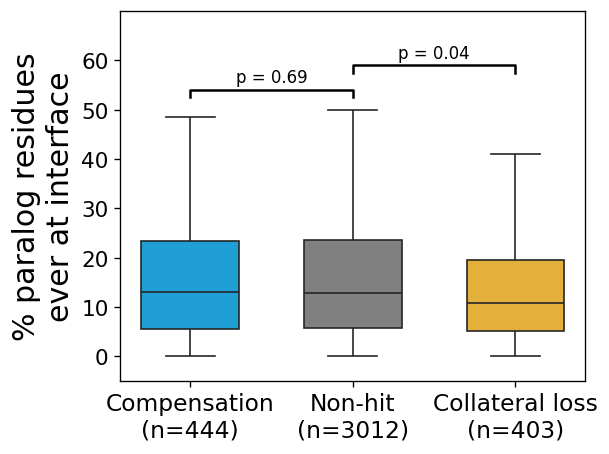

In [244]:
combined_ttest_and_boxplot('A1_perc_at_int', annotated_res, 'A1_interface', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


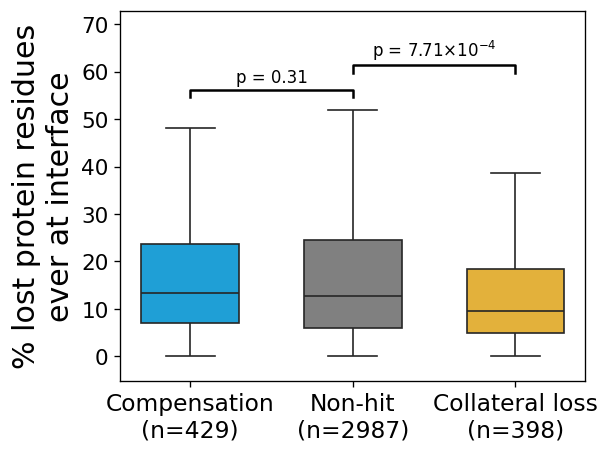

In [245]:
combined_ttest_and_boxplot('A2_perc_at_int', annotated_res, 'A2_interface', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


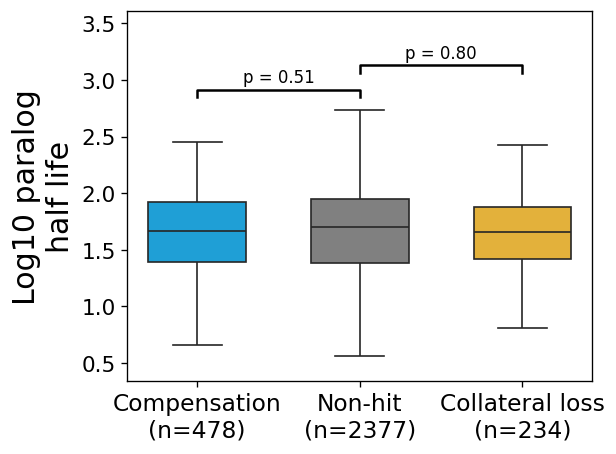

In [246]:
combined_ttest_and_boxplot('A1_hl', annotated_res, 'A1_hl', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


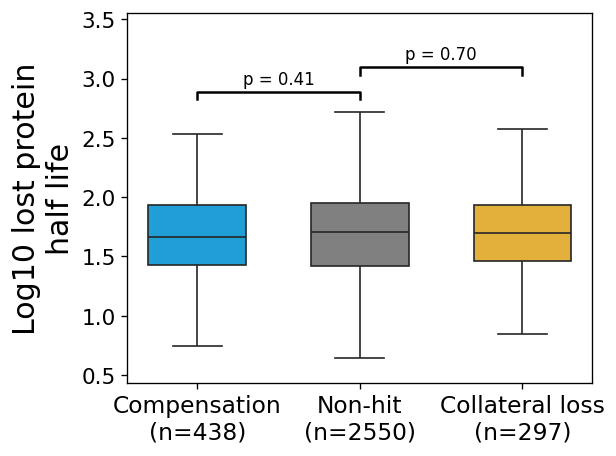

In [247]:
combined_ttest_and_boxplot('A2_hl', annotated_res, 'A2_hl', ylim=None, coldict=coldict, namedict=namedict, drop = False)


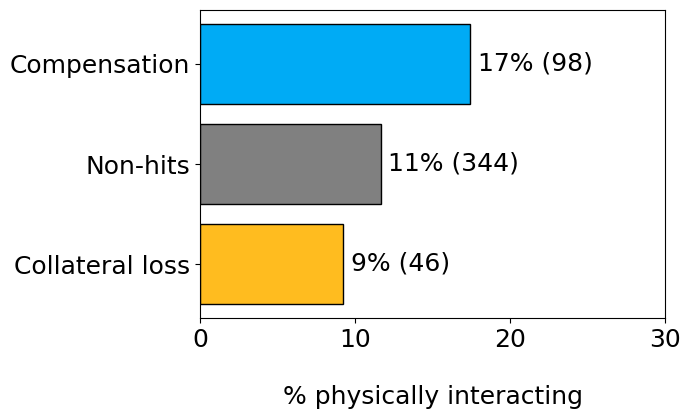

In [248]:
make_overlap_bar_chart(overlaps_prot, 'direct_interaction', 30, '% physically interacting', colordictloc = coldict, filename = 'direct_physical')


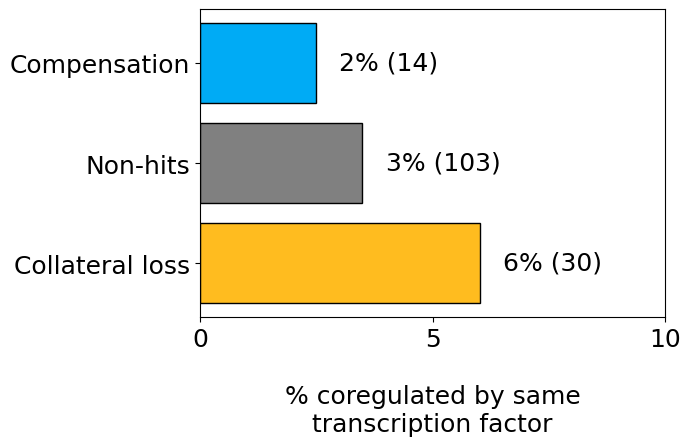

In [249]:
make_overlap_bar_chart(overlaps_prot, 'coreg_tf', 10, '% coregulated by same\ntranscription factor', colordictloc = coldict, filename = 'coreg')


## Figure EV5

In [250]:
perturb = pd.read_csv('../data/for_overlap/PerturbSeqRegulation.csv', index_col=0)
perturb['gene_pair'] = perturb['Regulated Gene Symbol'] + '_' + perturb['Target Gene Symbol']

commons = list(np.intersect1d(perturb.gene_pair.to_list(), overlaps_prot.gene_pair.to_list()))
perturb = perturb[perturb.gene_pair.isin(commons)]
prot_perturb_overlap = overlaps_prot[overlaps_prot.gene_pair.isin(commons)]

trans_comp_hits = overlaps_trans[overlaps_trans.compensation].gene_pair.to_list()
resid_comp_hits = overlaps_resid[overlaps_resid.compensation].gene_pair.to_list()

trans_cl_hits = overlaps_trans[overlaps_trans.collateral_loss].gene_pair.to_list()
resid_cl_hits = overlaps_resid[overlaps_resid.collateral_loss].gene_pair.to_list()

prot_perturb_overlap['prot_compensation'] = prot_perturb_overlap['compensation']
prot_perturb_overlap['trans_compensation'] = prot_perturb_overlap['gene_pair'].apply(lambda x: (x in trans_comp_hits))
prot_perturb_overlap['resid_compensation'] = prot_perturb_overlap['gene_pair'].apply(lambda x: (x in resid_comp_hits))
prot_perturb_overlap['resid_only_compensation'] = (prot_perturb_overlap['resid_compensation'] == True) & (prot_perturb_overlap['trans_compensation'] == False)

prot_perturb_overlap['prot_collateral_loss'] = prot_perturb_overlap['collateral_loss']
prot_perturb_overlap['trans_collateral_loss'] = prot_perturb_overlap['gene_pair'].apply(lambda x: (x in trans_cl_hits))
prot_perturb_overlap['resid_collateral_loss'] = prot_perturb_overlap['gene_pair'].apply(lambda x: (x in resid_cl_hits))
prot_perturb_overlap['resid_only_collateral_loss'] = (prot_perturb_overlap['resid_collateral_loss'] == True) & (prot_perturb_overlap['trans_collateral_loss'] == False)

perturb = perturb.rename(columns = {'Regulation':'perturb_result'})
prot_perturb_overlap = prot_perturb_overlap.merge(perturb[['gene_pair', 'perturb_result']], on = 'gene_pair', how = 'left')


/tmp/ipykernel_251061/51767199.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot_perturb_overlap['prot_compensation'] = prot_perturb_overlap['compensation']
/tmp/ipykernel_251061/51767199.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot_perturb_overlap['trans_compensation'] = prot_perturb_overlap['gene_pair'].apply(lambda x: (x in trans_comp_hits))
/tmp/ipykernel_251061/51767199.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [251]:
def run_categorical_fet(df, categorical_var, compare_values, test_type='compensation', data_type='prot', alpha=0.05):
    """
    Run Fisher's exact test for a categorical variable and return results.
    This version keeps the exact same logic as the original but removes the bar chart.
    """
    if len(compare_values) != 2:
        raise ValueError("compare_values must contain exactly two values to compare")
    
    subset_mask = df[categorical_var].isin(compare_values)
    subset_df = df[subset_mask].copy()
    
    subset_df['binary_cat'] = subset_df[categorical_var] == compare_values[0]
    
    resid_only_comp_col = 'resid_only_compensation'
    resid_only_loss_col = 'resid_only_collateral_loss'
    
    has_resid_only_comp = resid_only_comp_col in df.columns
    has_resid_only_loss = resid_only_loss_col in df.columns
    
    if test_type == 'resid_only_compensation':
        if has_resid_only_comp:
            test_mask = subset_df[resid_only_comp_col] == True
            
            exclude_mask = pd.Series(False, index=subset_df.index)
            
            for dt in ['prot', 'trans', 'resid']:
                if f"{dt}_compensation" in subset_df.columns:
                    exclude_mask = exclude_mask | (subset_df[f"{dt}_compensation"] == True)
                if f"{dt}_collateral_loss" in subset_df.columns:
                    exclude_mask = exclude_mask | (subset_df[f"{dt}_collateral_loss"] == True)
            
            if has_resid_only_loss:
                exclude_mask = exclude_mask | (subset_df[resid_only_loss_col] == True)
        else:
            return pd.DataFrame()
    elif test_type == 'resid_only_collateral_loss':
        if has_resid_only_loss:
            test_mask = subset_df[resid_only_loss_col] == True
            
            exclude_mask = pd.Series(False, index=subset_df.index)
            
            for dt in ['prot', 'trans', 'resid']:
                if f"{dt}_compensation" in subset_df.columns:
                    exclude_mask = exclude_mask | (subset_df[f"{dt}_compensation"] == True)
                if f"{dt}_collateral_loss" in subset_df.columns:
                    exclude_mask = exclude_mask | (subset_df[f"{dt}_collateral_loss"] == True)
            
            if has_resid_only_comp:
                exclude_mask = exclude_mask | (subset_df[resid_only_comp_col] == True)
        else:
            return pd.DataFrame()
    else:
        if data_type is None:
            return pd.DataFrame()
            
        comp_col = f"{data_type}_compensation"
        loss_col = f"{data_type}_collateral_loss"
        
        if test_type == 'compensation':
            if data_type == 'resid' and has_resid_only_comp:
                test_mask = (subset_df[comp_col] == True) | (subset_df[resid_only_comp_col] == True)
            else:
                test_mask = subset_df[comp_col] == True
                
            if data_type == 'resid' and has_resid_only_loss:
                exclude_mask = (subset_df[loss_col] == True) | (subset_df[resid_only_loss_col] == True)
            else:
                exclude_mask = subset_df[loss_col] == True
        elif test_type == 'collateral_loss':
            if data_type == 'resid' and has_resid_only_loss:
                test_mask = (subset_df[loss_col] == True) | (subset_df[resid_only_loss_col] == True)
            else:
                test_mask = subset_df[loss_col] == True
                
            if data_type == 'resid' and has_resid_only_comp:
                exclude_mask = (subset_df[comp_col] == True) | (subset_df[resid_only_comp_col] == True)
            else:
                exclude_mask = subset_df[comp_col] == True
        else:
            return pd.DataFrame()
    
    control_mask = ~test_mask & ~exclude_mask
    
    test_count = test_mask.sum()
    control_count = control_mask.sum()
    
    if test_count < 2 or control_count < 2:
        return pd.DataFrame({
            'Test Type': [test_type if data_type is None else f"{data_type}_{test_type}"],
            'Metric': [f"{categorical_var}: {compare_values[0]} vs {compare_values[1]}"],
            'Odds Ratio': [np.nan],
            'P-value': [np.nan],
            'Test %': [np.nan],
            'Control %': [np.nan],
            'N (Test)': [test_count],
            'N (Control)': [control_count],
            'Significant': [False]
        })
    
    test_pos = (test_mask & subset_df['binary_cat']).sum()
    test_neg = test_count - test_pos
    control_pos = (control_mask & subset_df['binary_cat']).sum()
    control_neg = control_count - control_pos
    
    contingency = [[test_pos, test_neg], [control_pos, control_neg]]
    
    try:
        odds_ratio, p_val = fisher_exact(contingency)
    except ValueError:
        return pd.DataFrame({
            'Test Type': [test_type if data_type is None else f"{data_type}_{test_type}"],
            'Metric': [f"{categorical_var}: {compare_values[0]} vs {compare_values[1]}"],
            'Odds Ratio': [np.nan],
            'P-value': [np.nan],
            'Test %': [np.nan],
            'Control %': [np.nan],
            'N (Test)': [test_count],
            'N (Control)': [control_count],
            'Significant': [False]
        })
    
    test_percent = (test_pos / test_count * 100) if test_count > 0 else np.nan
    control_percent = (control_pos / control_count * 100) if control_count > 0 else np.nan
    
    is_significant = p_val < alpha
    
    test_label = test_type if data_type is None else f"{data_type}_{test_type}"
    
    result_df = pd.DataFrame({
        'Test Type': [test_label],
        'Metric': [f"{categorical_var}: {compare_values[0]} vs {compare_values[1]}"],
        'Odds Ratio': [odds_ratio],
        'P-value': [p_val],
        f'{compare_values[0]} % (Test)': [test_percent],
        f'{compare_values[0]} % (Control)': [control_percent],
        'N (Test)': [test_count],
        'N (Control)': [control_count],
        'Significant': [is_significant]
    })
    
    return result_df

def run_categorical_fet_all(df, categorical_var, compare_values, data_types=None, test_types=None, alpha=0.05):
    """
    Run Fisher's exact test for all combinations of test types and data types.
    This is the same logic as the original function.
    """
    if data_types is None:
        data_types = ['prot', 'trans', 'resid']
    
    if test_types is None:
        test_types = ['compensation', 'collateral_loss']
        if 'resid_only_compensation' in df.columns:
            test_types.append('resid_only_compensation')
        if 'resid_only_collateral_loss' in df.columns:
            test_types.append('resid_only_collateral_loss')
    
    results = []
    
    for test_type in test_types:
        if test_type in ['resid_only_compensation', 'resid_only_collateral_loss']:
            result = run_categorical_fet(
                df, categorical_var, compare_values, 
                test_type=test_type, data_type=None,
                alpha=alpha
            )
            if not result.empty:
                results.append(result)
        else:
            for data_type in data_types:
                result = run_categorical_fet(
                    df, categorical_var, compare_values, 
                    test_type=test_type, data_type=data_type,
                    alpha=alpha
                )
                if not result.empty:
                    results.append(result)
    
    if not results:
        return pd.DataFrame()
    
    return pd.concat(results).reset_index(drop=True).sort_values('P-value')

def plot_OR_from_results(upreg_results_df, downreg_results_df=None, 
                     figsize=(10, 5), effect_type='compensation', filename=None):
    """
    Plot odds ratios from Fisher's exact test results for either compensation or collateral loss.
    Takes separate dataframes for upregulation and downregulation results.
    """
    # Filter for tests based on effect_type
    upreg_filtered = upreg_results_df[upreg_results_df['Test Type'].str.contains(effect_type)].copy()
    
    # Define the standard dataset categories for display - upregulated must be first/top
    interaction_datasets = [
        'A1 downregulated upon A2 knockdown',
        'A1 upregulated upon A2 knockdown'
    ]
    
    # Combine results into a single dataframe with proper display categories
    combined_results = []
    
    # Process upregulation results
    if not upreg_filtered.empty:
        upreg_filtered['Display_Category'] = 'A1 upregulated upon A2 knockdown'
        combined_results.append(upreg_filtered)
    
    # Process downregulation results if provided
    if downreg_results_df is not None:
        downreg_filtered = downreg_results_df[downreg_results_df['Test Type'].str.contains(effect_type)].copy()
        if not downreg_filtered.empty:
            downreg_filtered['Display_Category'] = 'A1 downregulated upon A2 knockdown'
            combined_results.append(downreg_filtered)
    
    # Combine all results
    if not combined_results:
        print(f"No {effect_type} results to plot")
        return
    
    filtered_results = pd.concat(combined_results, ignore_index=True)
    
    # Define colors - use same colors for both compensation and collateral loss
    colors = {
        'prot_compensation': '#A96DAE',       # Proteomic - purple
        'trans_compensation': '#C7A238',      # Transcriptional - gold
        'resid_only_compensation': '#5AACA8', # Post-transcriptional - teal
        'prot_collateral_loss': '#A96DAE',    # Same as compensation
        'trans_collateral_loss': '#C7A238',   # Same as compensation
        'resid_only_collateral_loss': '#5AACA8' # Same as compensation
    }
    
    # Simplified method labels for shared legend
    method_labels = {
        'prot_compensation': 'Proteomic hits',
        'trans_compensation': 'Transcriptional hits', 
        'resid_only_compensation': 'Post-transcriptional hits',
        'prot_collateral_loss': 'Proteomic hits',
        'trans_collateral_loss': 'Transcriptional hits',
        'resid_only_collateral_loss': 'Post-transcriptional hits'
    }
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each dataset (in proper order)
    for dataset in interaction_datasets:
        # Get data for this dataset
        dataset_results = filtered_results[filtered_results['Display_Category'] == dataset]
        
        if dataset_results.empty:
            continue
        
        # Plot each method - only plot the three main types
        for _, row in dataset_results.iterrows():
            test_type = row['Test Type']
            if test_type not in colors:
                continue
                
            or_value = row['Odds Ratio']
            is_significant = row['Significant']
            
            # Skip NaN values
            if np.isnan(or_value):
                continue
                
            if is_significant:
                # Significant: filled circle
                ax.scatter(or_value, dataset, color=colors[test_type], marker='o', s=180, zorder=10)
            else:
                # Not significant: hollow circle
                ax.scatter(or_value, dataset, facecolors='none', edgecolors=colors[test_type], marker='o', s=140, linewidth=2)
    
    # Set up the plot
    ax.set_xlabel("\nFishers Exact Test Odds Ratio", fontsize=14)
    ax.set_ylabel("", fontsize=13)
    ax.axvline(x=1, color='grey', linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=13)
    
    # Determine x-axis limits based on data
    x_values = filtered_results['Odds Ratio'].dropna().values
    if len(x_values) > 0:
        max_x = max(x_values)
        max_x = max(8, np.ceil(max_x * 1.1))  # Ensure at least 8
        ax.set_xlim(left=0, right=max_x)
    else:
        ax.set_xlim(left=0, right=8)  # Default if no data
    
    # Create legend for just the three main types
    legend_elements = []
    
    # Fixed legend order (transcriptional, proteomic, post-transcriptional)
    if effect_type == 'compensation':
        ordered_types = ['trans_compensation', 'prot_compensation', 'resid_only_compensation']
    else:
        ordered_types = ['trans_collateral_loss', 'prot_collateral_loss', 'resid_only_collateral_loss']
    
    # Add legend elements in fixed order
    for test_type in ordered_types:
        if test_type in filtered_results['Test Type'].values or test_type.replace('resid_only_', 'resid_') in filtered_results['Test Type'].values:
            legend_elements.append(Rectangle((0, 0), 1, 1, color=colors[test_type], label=method_labels[test_type]))
    
    # Add significance indicators to legend
    legend_elements.extend([
        Line2D([0], [0], marker='o', color='grey', label='p < 0.05', markersize=8, linestyle=''),
        Line2D([0], [0], marker='o', color='grey', label='p ≥ 0.05', markersize=8, linestyle='', linewidth=2, markerfacecolor='none')
    ])
    
    # Set background color and add legend
    ax.set_facecolor('#F7F7F7')  # Light grey background
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, handles=legend_elements, fontsize=12)
    
    if effect_type == 'compensation':
        formatted_effect_type = 'compensation'
    elif effect_type == 'collateral_loss':
        formatted_effect_type = 'collateral loss'

    # Set title based on effect_type
    title = f"Perturb-seq overlap with {formatted_effect_type}"
    plt.title(f'{title}\n', fontsize=18)
    
    # Set y-axis limits - only show datasets that have data
    displayed_datasets = [d for d in interaction_datasets if d in filtered_results['Display_Category'].values]
    if displayed_datasets:
        ax.set_yticks(range(len(displayed_datasets)))
        ax.set_yticklabels(displayed_datasets)
        ax.set_ylim(-0.5, len(displayed_datasets) - 0.5)
    
    plt.tight_layout()
    
    # Save if filename is provided
    if filename:
        plt.savefig(f'../output/figures/{filename}.svg', dpi=160, bbox_inches='tight')

In [252]:
pseq_overlap_results_upreg = run_categorical_fet_all(prot_perturb_overlap, 'perturb_result', ['upregulation', 'none'])
pseq_overlap_results_upreg


,Test Type,Metric,Odds Ratio,P-value,upregulation % (Test),upregulation % (Control),N (Test),N (Control),Significant
1,trans_compensation,perturb_result: upregulation vs none,7.339450,0.000241,4.385965,0.621118,228,805,True
0,prot_compensation,perturb_result: upregulation vs none,6.748413,0.000281,4.182510,0.642674,263,778,True
2,resid_compensation,perturb_result: upregulation vs none,3.851240,0.022746,4.347826,1.166490,115,943,True
4,trans_collateral_loss,perturb_result: upregulation vs none,3.404255,0.294294,2.083333,0.621118,48,805,False
6,resid_only_compensation,perturb_result: upregulation vs none,2.539062,0.378213,1.538462,0.611621,65,654,False
3,prot_collateral_loss,perturb_result: upregulation vs none,0.000000,1.000000,0.000000,0.642674,40,778,False
5,resid_collateral_loss,perturb_result: upregulation vs none,0.000000,1.000000,0.000000,1.166490,23,943,False
7,resid_only_collateral_loss,perturb_result: upregulation vs none,0.000000,1.000000,0.000000,0.611621,18,654,False


In [253]:
pseq_overlap_results_downreg = run_categorical_fet_all(prot_perturb_overlap, 'perturb_result', ['downregulation', 'none'])
pseq_overlap_results_downreg


,Test Type,Metric,Odds Ratio,P-value,downregulation % (Test),downregulation % (Control),N (Test),N (Control),Significant
7,resid_only_collateral_loss,perturb_result: downregulation vs none,4.513889,0.227208,5.263158,1.215805,19,658,False
5,resid_collateral_loss,perturb_result: downregulation vs none,3.683794,0.261650,4.166667,1.166490,24,943,False
1,trans_compensation,perturb_result: downregulation vs none,0.305810,0.320863,0.456621,1.477833,219,812,False
3,prot_collateral_loss,perturb_result: downregulation vs none,2.147222,0.401844,2.439024,1.150895,41,782,False
6,resid_only_compensation,perturb_result: downregulation vs none,1.269531,0.573779,1.538462,1.215805,65,658,False
0,prot_compensation,perturb_result: downregulation vs none,1.022487,1.000000,1.176471,1.150895,255,782,False
2,resid_compensation,perturb_result: downregulation vs none,0.770248,1.000000,0.900901,1.166490,111,943,False
4,trans_collateral_loss,perturb_result: downregulation vs none,0.000000,1.000000,0.000000,1.477833,47,812,False


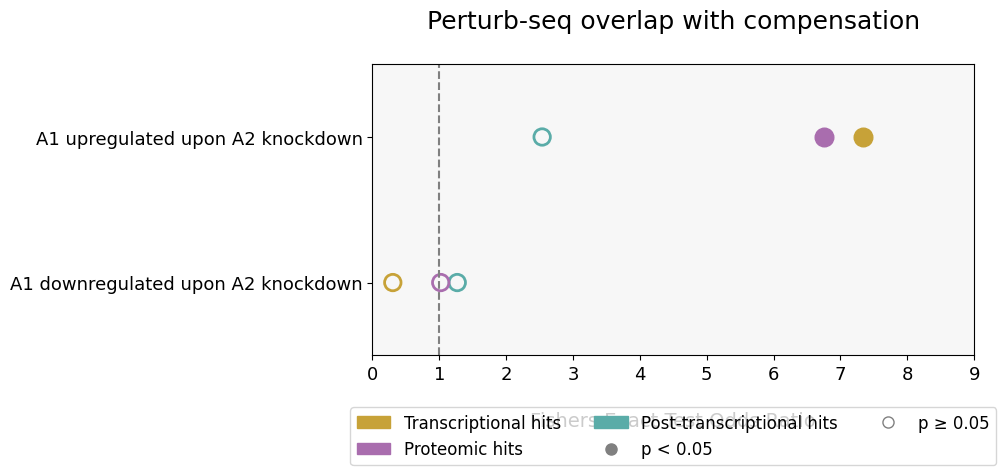

In [254]:
plot_OR_from_results(pseq_overlap_results_upreg, pseq_overlap_results_downreg, filename = 'pseq_overlap_compensation')

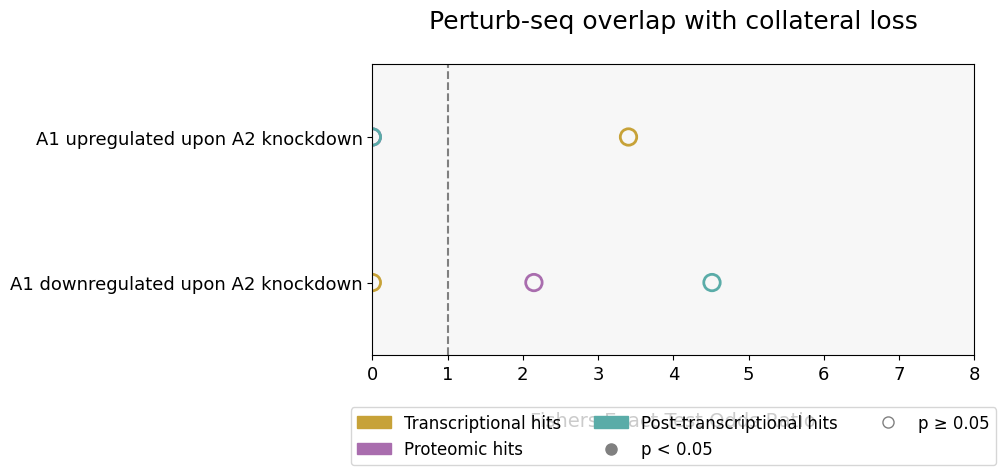

In [255]:

plot_OR_from_results(pseq_overlap_results_upreg, pseq_overlap_results_downreg, effect_type='collateral_loss', filename = 'pseq_overlap_CL')

## Appendix Figure S1

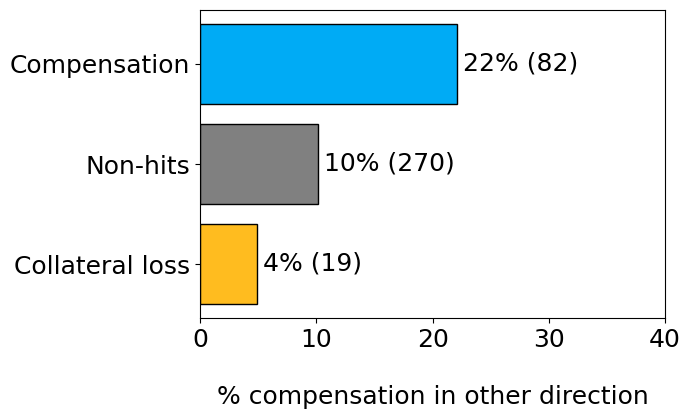

In [256]:
make_overlap_bar_chart(overlaps_prot, 'other_dir_comp', 40, '% compensation in other direction', colordictloc = coldict, filename = 'recip_comp', directional = True)


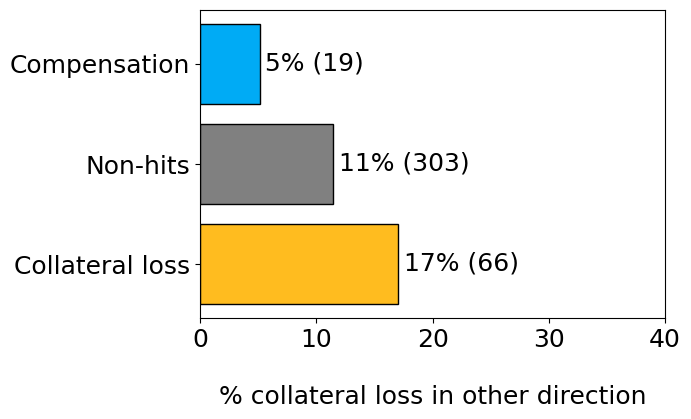

In [257]:
make_overlap_bar_chart(overlaps_prot, 'other_dir_cl', 40, '% collateral loss in other direction', colordictloc = coldict, filename = 'recip_cl', directional = True)


## Appendix Figure S2

/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


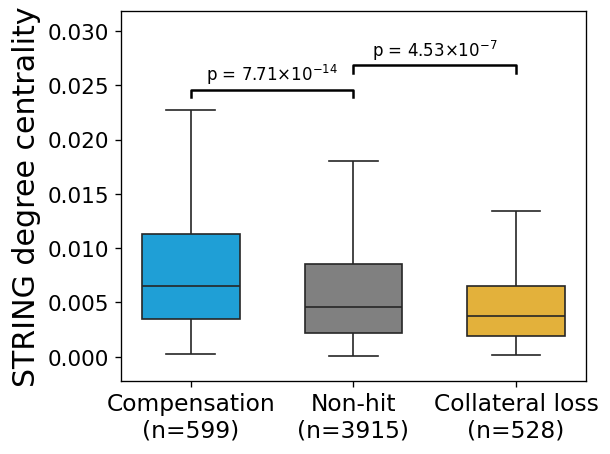

In [280]:
## Supplementary figure 5
combined_ttest_and_boxplot('string_dc_physical', annotated_res, 'string_dc', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


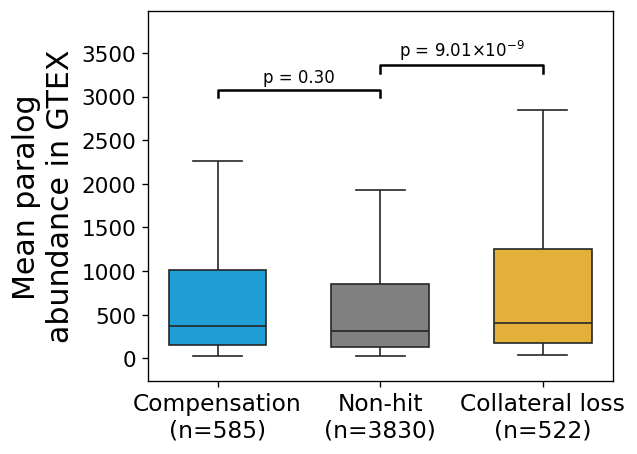

In [259]:
combined_ttest_and_boxplot('A1_abundance', annotated_res, 'A1_abundance', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y=colname, data=df2, palette=coldict, width=0.6,


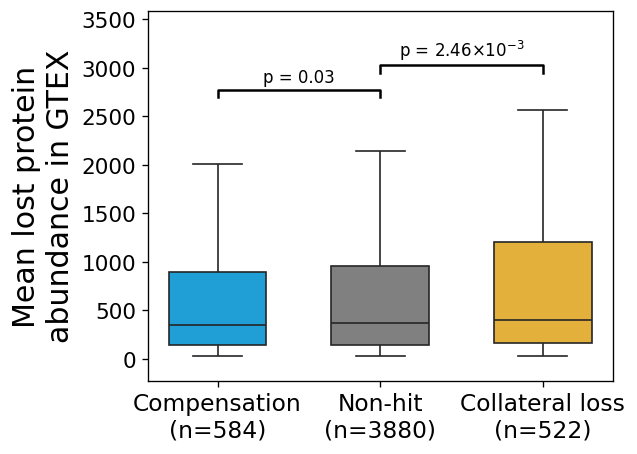

In [260]:

combined_ttest_and_boxplot('A2_abundance', annotated_res, 'A2_abundance', ylim=None, coldict=coldict, namedict=namedict, drop = False)


/tmp/ipykernel_251061/1981993307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = df2['category'].replace({'compensation': 'Compensation',
/tmp/ipykernel_251061/1981993307.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = pd.Categorical(df2['category'], categories=category_order, ordered=True)
/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

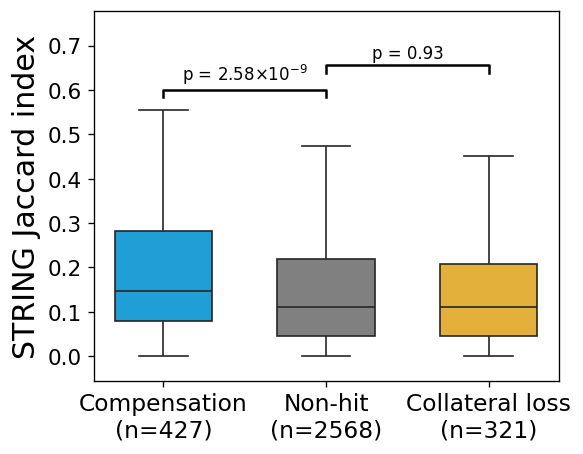

In [261]:

combined_ttest_and_boxplot('string_jaccard_physical', annotated_res, 'string_jaccard', ylim=None, coldict=coldict, namedict=namedict)


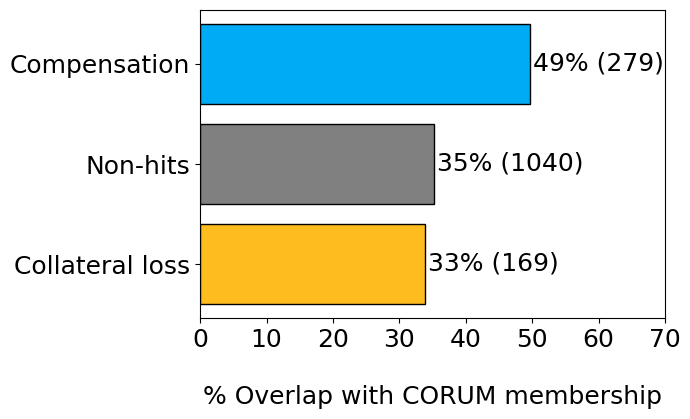

In [262]:
make_overlap_bar_chart(overlaps_prot, 'in_PC_CORUM', 70, '% Overlap with CORUM membership', colordictloc = coldict, filename = 'pc_corum')


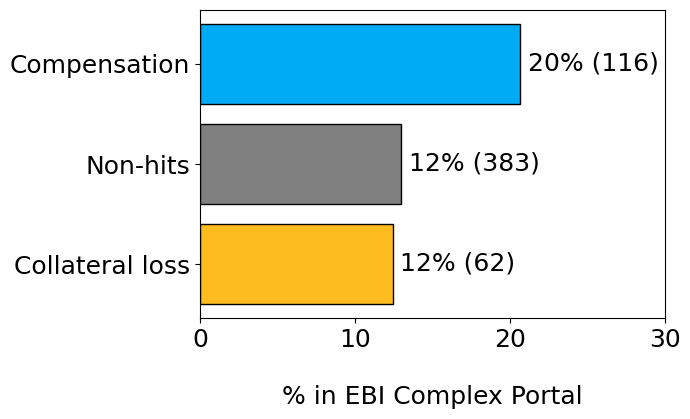

In [263]:
make_overlap_bar_chart(overlaps_prot, 'in_PC_EBI', 30, '% in EBI Complex Portal', colordictloc = coldict, filename = 'ebi')

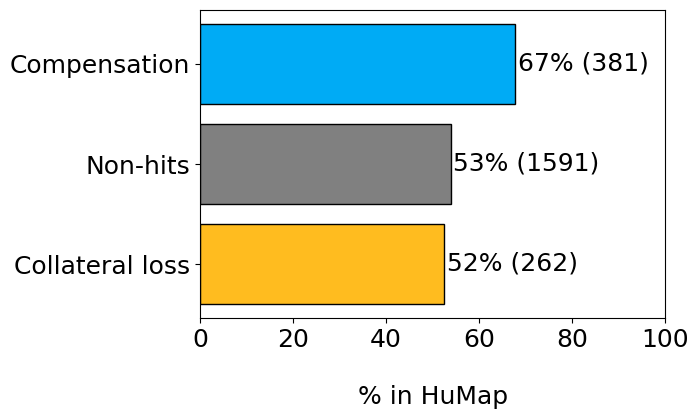

In [264]:
make_overlap_bar_chart(overlaps_prot, 'in_PC_humap', 100, '% in HuMap', colordictloc = coldict, filename = 'humap')


/tmp/ipykernel_251061/1981993307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = df2['category'].replace({'compensation': 'Compensation',
/tmp/ipykernel_251061/1981993307.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['category'] = pd.Categorical(df2['category'], categories=category_order, ordered=True)
/tmp/ipykernel_251061/1981993307.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

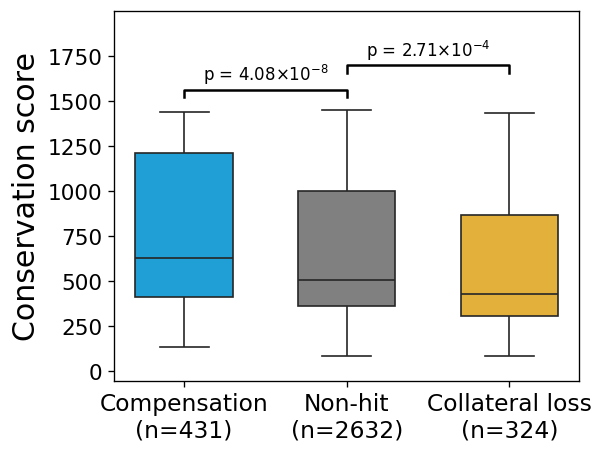

In [265]:
combined_ttest_and_boxplot('conservation_score', annotated_res, 'cons_score', ylim=None, coldict=coldict, namedict=namedict)


## Appendix Figure S3

In [266]:
def run_symmetric_tests(df, variables, figsize=(8, 5), alpha=0.05, drop_duplicates=True):
    results = []
    
    if drop_duplicates:
        df = df.drop_duplicates(subset='sorted_gene_pair')
    
    for test_type in ['compensation', 'collateral_loss']:
        if test_type == 'compensation':
            symmetric_mask = (df['compensation'] == True) & (df['other_dir_comp'] == True)
            asymmetric_mask = (df['compensation'] == True) & (df['other_dir_comp'] == False) & df['other_dir_comp'].notna()
            nonhit_mask = ~((df['compensation'] == True) | (df['collateral_loss'] == True))
        else:
            symmetric_mask = (df['collateral_loss'] == True) & (df['other_dir_cl'] == True)
            asymmetric_mask = (df['collateral_loss'] == True) & (df['other_dir_cl'] == False) & df['other_dir_cl'].notna()
            nonhit_mask = ~((df['compensation'] == True) | (df['collateral_loss'] == True))
        
        symmetric_count = symmetric_mask.sum()
        asymmetric_count = asymmetric_mask.sum()
        nonhit_count = nonhit_mask.sum()
        
        for var in variables:
            is_categorical = (df[var].dtype == bool) or (df[var].dtype.name == 'category') or (len(df[var].unique()) <= 5)
            
            if is_categorical:
                if df[var].dtype != bool:
                    category_values = df[var].dropna().unique()
                    if len(category_values) > 0:
                        category_label = str(category_values[0])
                        is_reference = df[var] == category_values[0]
                    else:
                        continue
                else:
                    category_label = "True"
                    is_reference = df[var]
                
                symmetric_pos = (symmetric_mask & is_reference).sum()
                symmetric_neg = symmetric_count - symmetric_pos
                asymmetric_pos = (asymmetric_mask & is_reference).sum()
                asymmetric_neg = asymmetric_count - asymmetric_pos
                nonhit_pos = (nonhit_mask & is_reference).sum()
                nonhit_neg = nonhit_count - nonhit_pos
                
                if symmetric_count < 2 or asymmetric_count < 2:
                    continue
                
                contingency = [[symmetric_pos, symmetric_neg], [asymmetric_pos, asymmetric_neg]]
                try:
                    odds_ratio, p_val = fisher_exact(contingency)
                except:
                    continue
                
                symmetric_percent = (symmetric_pos / symmetric_count * 100) if symmetric_count > 0 else np.nan
                asymmetric_percent = (asymmetric_pos / asymmetric_count * 100) if asymmetric_count > 0 else np.nan
                nonhit_percent = (nonhit_pos / nonhit_count * 100) if nonhit_count > 0 else np.nan
                
                is_significant = p_val < alpha
                
                results.append({
                    'Test Type': f"symmetric_vs_asymmetric_{test_type}",
                    'Variable': var,
                    'Categorical': True,
                    'Statistic': odds_ratio,
                    'P-value': p_val,
                    'Symmetric Value': symmetric_percent,
                    'Asymmetric Value': asymmetric_percent,
                    'Non-hit Value': nonhit_percent,
                    'N (Symmetric)': symmetric_count,
                    'N (Asymmetric)': asymmetric_count,
                    'N (Non-hit)': nonhit_count,
                    'Significant': is_significant
                })
                
                if is_significant:
                    colors = ['#0072B2', '#56B4E9', '#999999']
                    
                    fig, ax = plt.subplots(figsize=figsize)
                    
                    categories = [f'Symmetric\n{test_type.capitalize()}', f'Asymmetric\n{test_type.capitalize()}', 'Non-hit']
                    values = [symmetric_percent, asymmetric_percent, nonhit_percent]
                    counts = [symmetric_pos, asymmetric_pos, nonhit_pos]
                    totals = [symmetric_count, asymmetric_count, nonhit_count]
                    
                    ax.barh(categories, values, color=colors, alpha=1, edgecolor='black')
                    
                    max_value = max(v for v in values if not np.isnan(v))
                    xlim = min(100, max(30, np.ceil(max_value / 10) * 10 * 1.3))
                    
                    if xlim < 30:
                        tick_interval = 5
                    elif xlim > 70:
                        tick_interval = 20
                    else:
                        tick_interval = 10
                        
                    xticks = np.arange(0, xlim + tick_interval, tick_interval)
                    if xticks[-1] > xlim:
                        xticks = xticks[:-1]
                    elif xticks[-1] < xlim:
                        xticks = np.append(xticks, xlim - (xlim % tick_interval) + tick_interval)
                        
                    ax.set_xlim(0, xlim)
                    ax.set_xticks(xticks)
                    ax.set_xticklabels([f'{int(x)}' for x in xticks])
                    ax.tick_params(axis='x', labelsize=18)
                    ax.tick_params(axis='y', labelsize=18)
                    
                    ax.set_title(f"{var}: Symmetric vs. Asymmetric {test_type.capitalize()}\np={p_val:.2e}, OR={odds_ratio:.2f}", fontsize=18)
                    ax.set_xlabel(f'% {category_label}', fontsize=18)
                    
                    def format_percentage(value):
                        if value >= 1:
                            return f'{int(value)}%'
                        elif value > 0:
                            return f'{value:.1g}%'
                        else:
                            return '0%'
                    
                    for i, (value, count, total) in enumerate(zip(values, counts, totals)):
                        if not np.isnan(value):
                            formatted_value = format_percentage(value)
                            ax.text(value + 0.5, i, f'{formatted_value} ({count}/{total})', ha='left', va='center', fontsize=18)
                    
                    filename = f"../output/figures/{var}_{test_type}_barchart.svg"
                    plt.savefig(filename, dpi=120, bbox_inches='tight')
                    
                    plt.tight_layout()
                    plt.show()
            
            else:
                symmetric_data = df[symmetric_mask][var].dropna()
                asymmetric_data = df[asymmetric_mask][var].dropna()
                nonhit_data = df[nonhit_mask][var].dropna()
                
                if len(symmetric_data) < 2 or len(asymmetric_data) < 2:
                    continue
                
                t_stat, p_val = stats.ttest_ind(symmetric_data, asymmetric_data, equal_var=True)
                
                asymmetric_nonhit_p = stats.ttest_ind(asymmetric_data, nonhit_data, equal_var=True).pvalue if len(nonhit_data) > 0 else np.nan
                
                is_significant = p_val < alpha
                
                results.append({
                    'Test Type': f"symmetric_vs_asymmetric_{test_type}",
                    'Variable': var,
                    'Categorical': False,
                    'Statistic': t_stat,
                    'P-value': p_val,
                    'Symmetric Value': symmetric_data.mean(),
                    'Asymmetric Value': asymmetric_data.mean(),
                    'Non-hit Value': nonhit_data.mean() if len(nonhit_data) > 0 else np.nan,
                    'N (Symmetric)': len(symmetric_data),
                    'N (Asymmetric)': len(asymmetric_data),
                    'N (Non-hit)': len(nonhit_data),
                    'Significant': is_significant
                })
                
                if is_significant:
                    plt.figure(figsize=(5, 4), dpi=120)
                    
                    categories = ['Symmetric\n' + test_type.capitalize(), 'Asymmetric\n' + test_type.capitalize(), 'Non-hit']
                    
                    temp_data = []
                    for i, category in enumerate(categories):
                        if i == 0:
                            for val in symmetric_data:
                                temp_data.append({'category': category, 'value': val})
                        elif i == 1:
                            for val in asymmetric_data:
                                temp_data.append({'category': category, 'value': val})
                        else:
                            for val in nonhit_data:
                                temp_data.append({'category': category, 'value': val})
                    
                    temp_df = pd.DataFrame(temp_data)
                    
                    if test_type == 'compensation':
                        coldict = {'Symmetric\n' + test_type.capitalize(): '#0072B2', 
                                   'Asymmetric\n' + test_type.capitalize(): '#56B4E9', 
                                   'Non-hit': '#999999'}
                    else:
                        coldict = {'Symmetric\n' + test_type.capitalize(): '#0072B2', 
                                   'Asymmetric\n' + test_type.capitalize(): '#56B4E9', 
                                   'Non-hit': '#999999'}
                    
                    box_plot = sns.boxplot(x='category', y='value', data=temp_df, palette=coldict, width=0.6, 
                                          flierprops={'marker': 'none'})
                    
                    plt.xlabel('')
                    plt.xticks(fontsize=14)
                    
                    ylab = namedict[var]
                    if '\n' not in ylab and len(ylab) > 30:
                        words = ylab.split()
                        char_count = 0
                        first_line = []
                        for word in words:
                            if char_count + len(word) <= len(ylab) // 2:
                                first_line.append(word)
                                char_count += len(word) + 1
                            else:
                                break
                        ylab = ' '.join(first_line) + '\n' + ' '.join(words[len(first_line):])
                    plt.ylabel(ylab, fontsize=18)
                    plt.yticks(fontsize=13)
                    
                    whiskers = [item.get_ydata() for item in box_plot.lines if len(item.get_ydata()) == 2]
                    whisker_mins = [min(whisker) for whisker in whiskers]
                    whisker_maxs = [max(whisker) for whisker in whiskers]
                    ymin = min(whisker_mins)
                    ymax = max(whisker_maxs)
                    y_range = ymax - ymin
                    padding = 0.1 * y_range
                    
                    plt.ylim(ymin - padding, ymax + padding + y_range * 0.3)
                    
                    def add_pvalue(pvalue, x1, x2, y, h):
                        pvalue_rounded = f"{pvalue:.2e}" if pvalue < 0.01 else f"{pvalue:.2f}"
                        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
                        plt.text((x1+x2)*.5, y+h*1.5, f"p = {pvalue_rounded}", ha='center', va='bottom', fontsize=10)
                    
                    pvalue_y = ymax + y_range * 0.05
                    
                    add_pvalue(p_val, 0, 1, pvalue_y, y_range * 0.03)
                    
                    if not np.isnan(asymmetric_nonhit_p):
                        add_pvalue(asymmetric_nonhit_p, 1, 2, pvalue_y + y_range * 0.1, y_range * 0.03)
                    
                    filename = f"../output/figures/{var}_{test_type}_boxplot.svg"
                    plt.savefig(filename, dpi=120, bbox_inches='tight')
                    
                    plt.tight_layout()
                    plt.show()
    
    if not results:
        return pd.DataFrame()
    
    return pd.DataFrame(results).sort_values('P-value')

In [267]:
from pandarallel import pandarallel
pandarallel.initialize(nb_workers=19, progress_bar=False)
apply_func = lambda df, func: df.parallel_apply(func)

INFO: Pandarallel will run on 19 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [268]:
all_comp_results = set(prot_res[prot_res.compensation].gene_pair)
all_cl_results = set(prot_res[prot_res.collateral_loss].gene_pair)
all_tested = set(prot_res.gene_pair)

In [269]:
annotated_res["other_dir_comp"] = apply_func(annotated_res["gene_pair"],
        lambda x: f"{x.split('_')[1]}_{x.split('_')[0]}" in all_comp_results 
                  if f"{x.split('_')[1]}_{x.split('_')[0]}" in all_tested else np.nan)

annotated_res["other_dir_cl"] = apply_func(
            annotated_res["gene_pair"],
            lambda x: f"{x.split('_')[1]}_{x.split('_')[0]}" in all_cl_results 
                    if f"{x.split('_')[1]}_{x.split('_')[0]}" in all_tested else np.nan)



In [270]:
run_symmetric_tests(
    annotated_res,
    ['string_jaccard_physical', 'bg_jaccard', 'conservation_score',
      'sequence_identity', 
     'family_size'],
       drop_duplicates = True)


,Test Type,Variable,Categorical,Statistic,P-value,Symmetric Value,Asymmetric Value,Non-hit Value,N (Symmetric),N (Asymmetric),N (Non-hit),Significant
5,symmetric_vs_asymmetric_collateral_loss,string_jaccard_physical,False,1.946914,0.053128,0.197126,0.145091,0.149684,32,147,2568,False
1,symmetric_vs_asymmetric_compensation,bg_jaccard,False,1.746189,0.082321,0.149982,0.116299,0.076922,41,160,2655,False
4,symmetric_vs_asymmetric_compensation,family_size,False,-1.635661,0.103483,4.878049,5.801242,7.369173,41,161,2660,False
3,symmetric_vs_asymmetric_compensation,sequence_identity,False,1.262404,0.208274,0.462886,0.420372,0.401556,41,161,2660,False
0,symmetric_vs_asymmetric_compensation,string_jaccard_physical,False,1.125074,0.261920,0.217085,0.185776,0.149684,41,159,2568,False
9,symmetric_vs_asymmetric_collateral_loss,family_size,False,-0.745451,0.456961,7.000000,7.529801,7.369173,33,151,2660,False
2,symmetric_vs_asymmetric_compensation,conservation_score,False,0.731998,0.465040,823.219512,770.025316,666.038374,41,158,2632,False
6,symmetric_vs_asymmetric_collateral_loss,bg_jaccard,False,0.216493,0.828846,0.070820,0.067771,0.076922,33,151,2655,False
7,symmetric_vs_asymmetric_collateral_loss,conservation_score,False,-0.166914,0.867623,614.212121,626.311258,666.038374,33,151,2632,False
8,symmetric_vs_asymmetric_collateral_loss,sequence_identity,False,-0.097774,0.922219,0.403021,0.406125,0.401556,33,151,2660,False


/home/administrator/venv_jun23/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1182: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
/home/administrator/venv_jun23/lib/python3.8/site-packages/scipy/stats/_stats_py.py:6337: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
/tmp/ipykernel_251061/1262922585.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y='value', data=temp_df, palette=coldict, width=0.6,


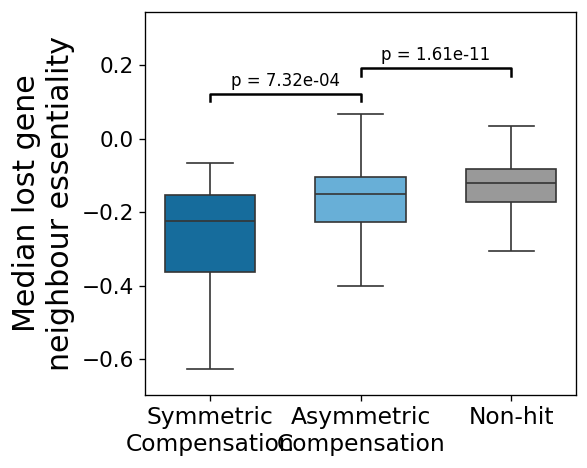

/tmp/ipykernel_251061/1262922585.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y='value', data=temp_df, palette=coldict, width=0.6,


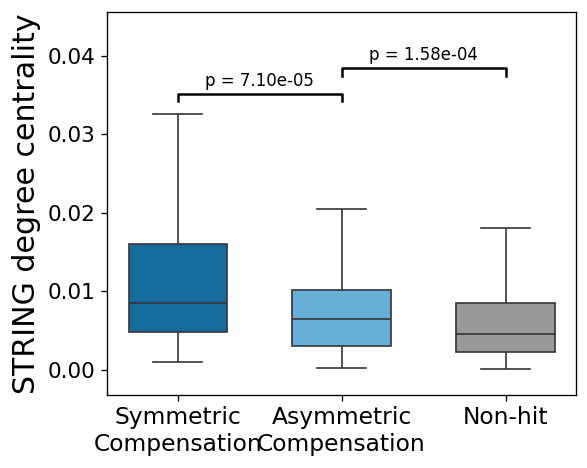

/tmp/ipykernel_251061/1262922585.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot = sns.boxplot(x='category', y='value', data=temp_df, palette=coldict, width=0.6,


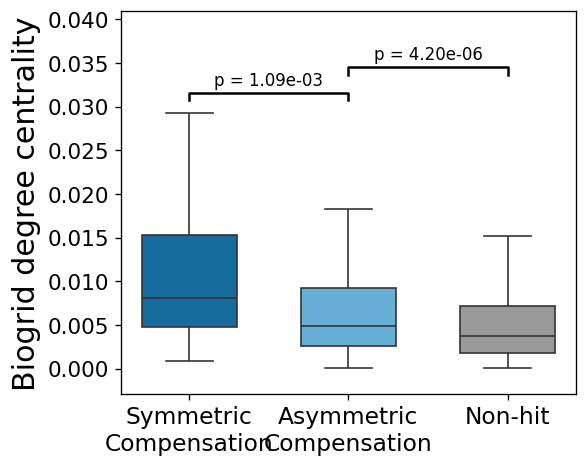

/home/administrator/venv_jun23/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1182: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
/home/administrator/venv_jun23/lib/python3.8/site-packages/scipy/stats/_stats_py.py:6337: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2


,Test Type,Variable,Categorical,Statistic,P-value,Symmetric Value,Asymmetric Value,Non-hit Value,N (Symmetric),N (Asymmetric),N (Non-hit),Significant
9,symmetric_vs_asymmetric_compensation,string_dc_physical,False,4.018625,0.000071,0.014634,0.008695,0.006875,82,287,3915,True
8,symmetric_vs_asymmetric_compensation,A2_median_neighbour_ess,False,-3.406005,0.000732,-0.282734,-0.206258,-0.152708,82,287,3913,True
10,symmetric_vs_asymmetric_compensation,biogrid_dc,False,3.293064,0.001087,0.013448,0.008513,0.006231,82,288,3991,True
11,symmetric_vs_asymmetric_collateral_loss,A1_length,False,1.924588,0.055016,822.257576,694.698758,634.364137,66,322,3993,False
21,symmetric_vs_asymmetric_collateral_loss,biogrid_dc,False,-1.791721,0.073961,0.003470,0.004547,0.006231,66,322,3991,False
12,symmetric_vs_asymmetric_collateral_loss,A2_length,False,1.733242,0.083851,822.257576,702.366460,632.908840,66,322,3993,False
0,symmetric_vs_asymmetric_compensation,A1_length,False,1.728604,0.084717,827.170732,694.685121,634.364137,82,289,3993,False
1,symmetric_vs_asymmetric_compensation,A2_length,False,1.555553,0.120672,827.170732,694.574394,632.908840,82,289,3993,False
18,symmetric_vs_asymmetric_collateral_loss,A2_abundance,False,1.344023,0.179747,1824.320357,1226.925147,1053.868255,65,315,3880,False
20,symmetric_vs_asymmetric_collateral_loss,string_dc_physical,False,-1.288854,0.198229,0.004551,0.005366,0.006875,65,319,3915,False


In [279]:
run_symmetric_tests(
    annotated_res,
    ['A1_length', 'A2_length','A1_perc_at_int', 'A2_perc_at_int', 'A1_hl', 'A2_hl', 'A1_abundance',
       'A2_abundance','A2_median_neighbour_ess', 'string_dc_physical', 'biogrid_dc'],
       drop_duplicates = False)


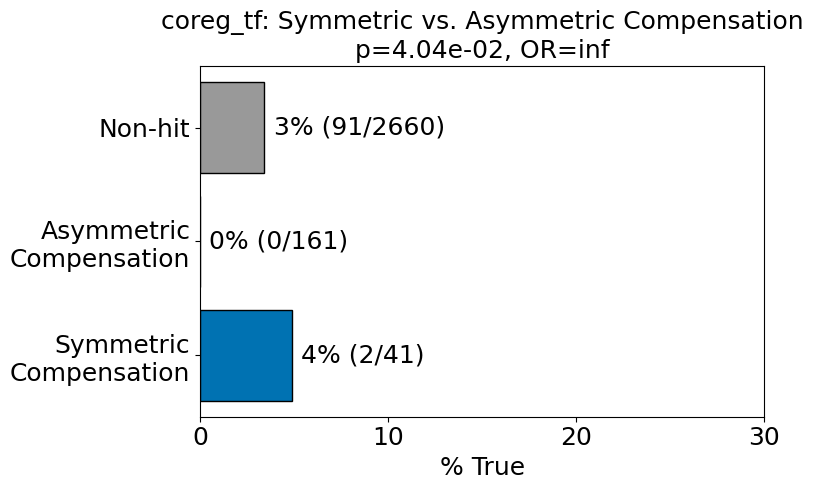

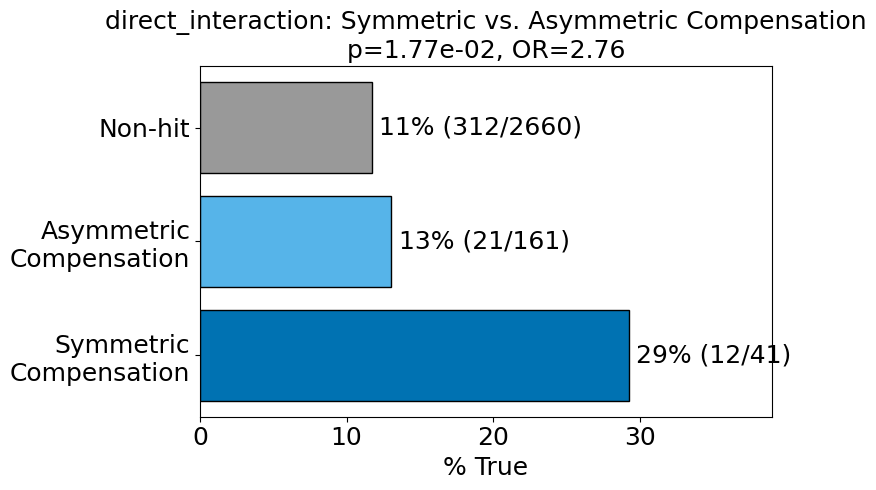

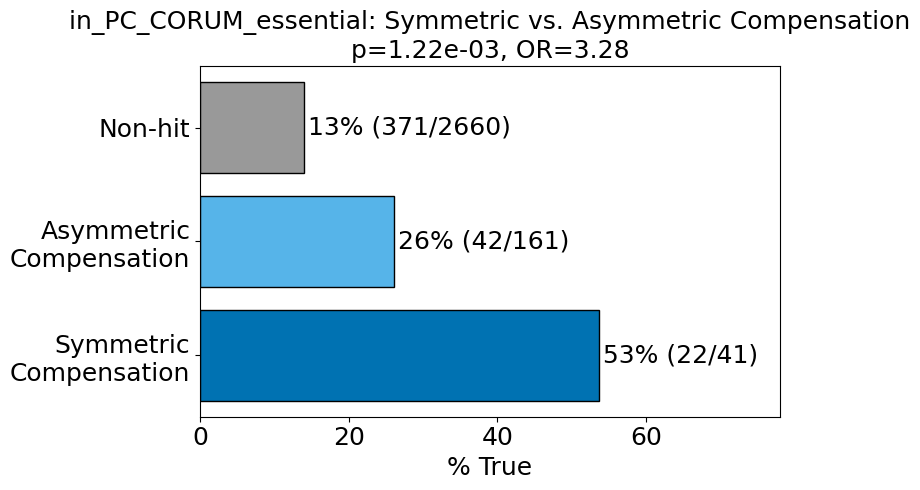

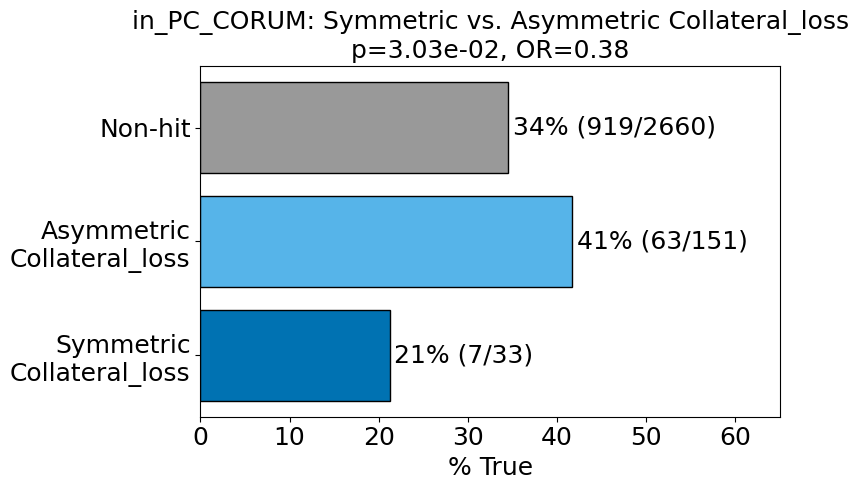

,Test Type,Variable,Categorical,Statistic,P-value,Symmetric Value,Asymmetric Value,Non-hit Value,N (Symmetric),N (Asymmetric),N (Non-hit),Significant
4,symmetric_vs_asymmetric_compensation,in_PC_CORUM_essential,True,3.280702,0.001221,53.658537,26.086957,13.947368,41,161,2660,True
1,symmetric_vs_asymmetric_compensation,direct_interaction,True,2.758621,0.017685,29.268293,13.043478,11.729323,41,161,2660,True
17,symmetric_vs_asymmetric_collateral_loss,in_PC_CORUM,True,0.376068,0.030346,21.212121,41.721854,34.548872,33,151,2660,True
0,symmetric_vs_asymmetric_compensation,coreg_tf,True,inf,0.040392,4.878049,0.000000,3.421053,41,161,2660,True
6,symmetric_vs_asymmetric_compensation,in_PC_CORUM,True,1.980685,0.055642,58.536585,41.614907,34.548872,41,161,2660,False
13,symmetric_vs_asymmetric_collateral_loss,bronze_standard_SL,True,0.538306,0.169145,27.272727,41.059603,40.225564,33,151,2660,False
15,symmetric_vs_asymmetric_collateral_loss,in_PC_CORUM_essential,True,0.230903,0.204980,3.030303,11.920530,13.947368,33,151,2660,False
5,symmetric_vs_asymmetric_compensation,lenient_comb_hit,True,0.617222,0.272024,26.829268,37.267081,33.872180,41,161,2660,False
10,symmetric_vs_asymmetric_compensation,closest_pair,True,1.502262,0.295081,58.536585,48.447205,38.721805,41,161,2660,False
14,symmetric_vs_asymmetric_collateral_loss,strict_comb_hit,True,1.895604,0.327226,15.151515,8.609272,9.436090,33,151,2660,False


In [272]:
run_symmetric_tests(
    overlaps_prot,
    ['coreg_tf', 'direct_interaction','bronze_standard_SL',
       'strict_comb_hit', 'in_PC_CORUM_essential',
       'lenient_comb_hit', 'in_PC_CORUM',
       'in_PC_CORUM_both', 'in_PC_EBI',
       'in_PC_humap', 'closest_pair'],
       drop_duplicates = True)


### Appendix Figures S4 and S5 created in logistic regression notebook

## Appendix Figure S6

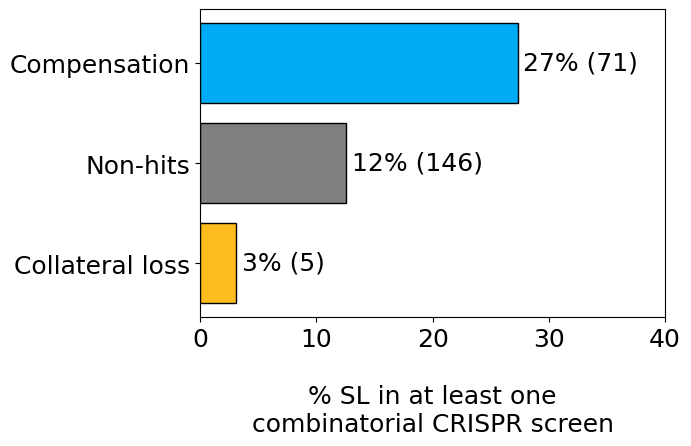

In [273]:
make_overlap_bar_chart(overlaps_prot, 'lenient_comb_hit', 40, '% SL in at least one\ncombinatorial CRISPR screen', colordictloc = coldict, filename = 'lenientSL')


### Appendix Figure S7 created in Inkscape

## Appendix Figure S8

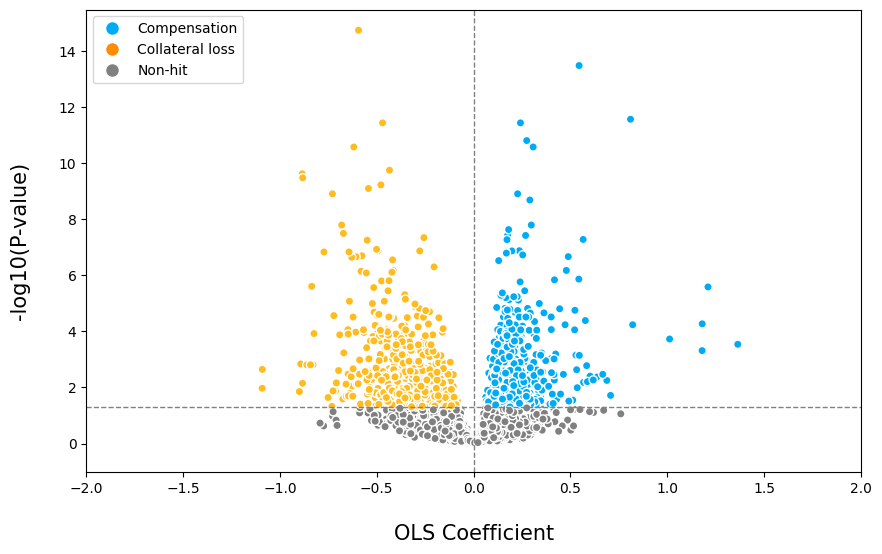

In [274]:
make_volcano_plot(trans_res, filename = 'trans', sigcutoff = 0.05, colordict = coldict)


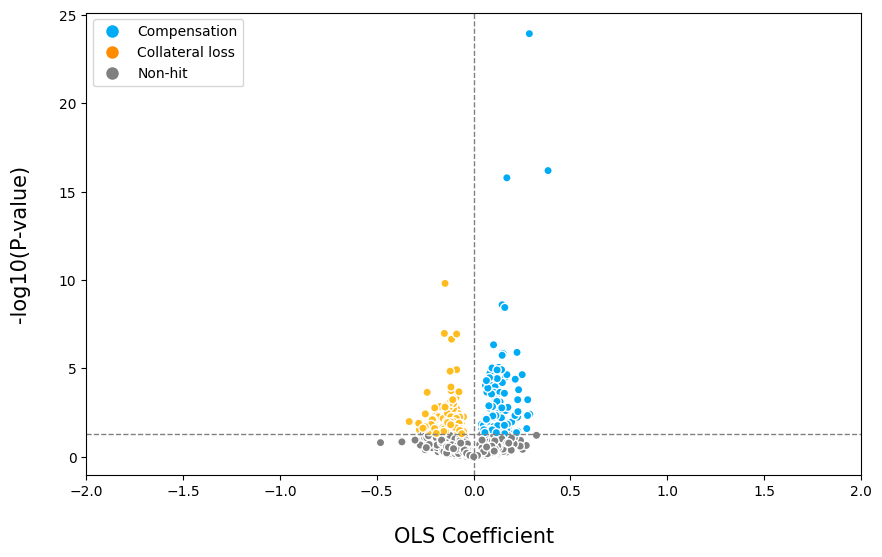

In [275]:
make_volcano_plot(resid_res, filename = 'resid', sigcutoff = 0.05, colordict = coldict)


## Appendix Figure S9

/tmp/ipykernel_251061/3636089769.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sig'] = (df['FET_p'] < 0.05) & (df['FET_p_adj'] < FDR)
/tmp/ipykernel_251061/3636089769.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['index'] = df['interaction_dataset'] + '_' + df['hit_type']
/tmp/ipykernel_251061/3636089769.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

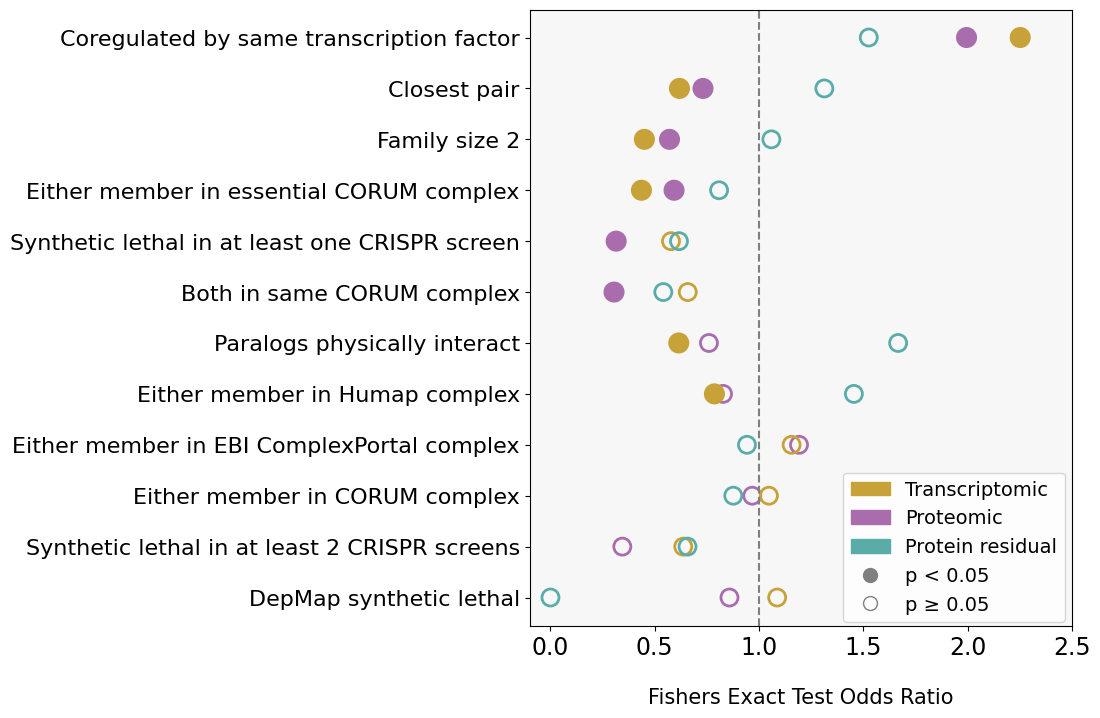

In [276]:
plot_OR('collateral_loss', 0.05, fish_prot_sorted, df2=fish_trans_sorted,df3=fish_res_sorted, 
                    df1_label='Proteomic', df2_label='Transcriptomic', df3_label ='Protein residual', 
                    displaydf=False, ylabel_dict = ydict, rightxlim=2.5)


## Appendix Figure S10

/tmp/ipykernel_251061/2476909863.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Category', y='num_ub_sites', data=ubsite_df,
/tmp/ipykernel_251061/2476909863.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels_with_sizes, rotation=0, ha='center')


Comparison: CORUM complex size >10 vs In CORUM
Median CORUM complex size >10: 14.0
Median In CORUM: 10.0
Sample size: n=193 and n=471
Mann-Whitney U statistic: 53576.5
P-value: 2.92×10^-4
Effect size (Cliff's Delta): 0.179
Interpretation: small effect (higher)

Comparison: In CORUM vs Post-trans CL
Median In CORUM: 10.0
Median Post-trans CL: 10.0
Sample size: n=471 and n=147
Mann-Whitney U statistic: 36239.0
P-value: 0.3910
Effect size (Cliff's Delta): 0.047
Interpretation: negligible effect (higher)

Comparison: Post-trans CL vs Trans exclusive CL
Median Post-trans CL: 10.0
Median Trans exclusive CL: 4.0
Sample size: n=147 and n=201
Mann-Whitney U statistic: 19221.0
P-value: 1.50×10^-6
Effect size (Cliff's Delta): 0.301
Interpretation: small effect (higher)

Comparison: Trans exclusive CL vs Never hits
Median Trans exclusive CL: 4.0
Median Never hits: 7.0
Sample size: n=201 and n=2180
Mann-Whitney U statistic: 178551.5
P-value: 1.34×10^-5
Effect size (Cliff's Delta): -0.185
Interpreta

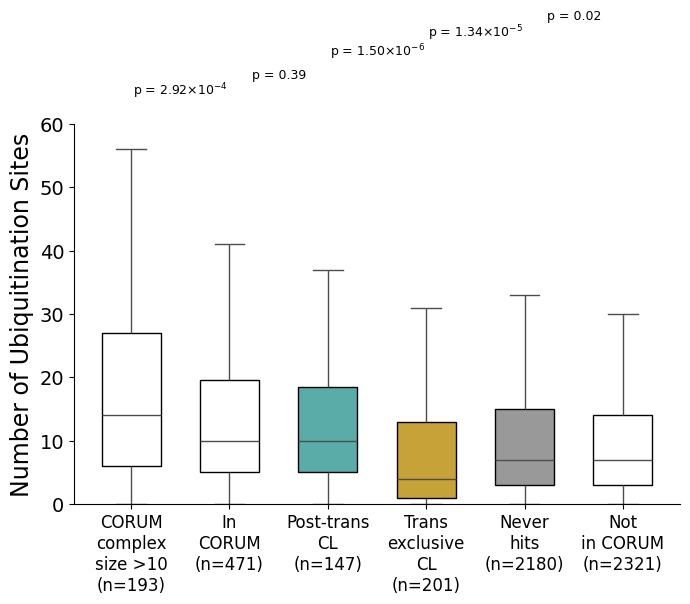

In [277]:
category_order_CL = ['CORUM\ncomplex\nsize >10', 'In\nCORUM', 'Post-trans\nCL', 'Trans\nexclusive\nCL','Never\nhits', 'Not\nin CORUM']

ub_color_dict_CL = {
    'CORUM\ncomplex\nsize >10': 'white',
    'In\nCORUM': 'white',
    'Post-trans\nCL': '#5AACA8',
    'Trans\nexclusive\nCL': '#C7A238',
    'Never\nhits': '#999999ff',
    'Not\nin CORUM': 'white'
}


def create_ubsite_df_CL(not_corum_prots, all_corum_prots, big_complex_prots, all_post_trans_A1s_CL, all_trans_A1s_CL, all_non_hit_A1s, ubdict):
    ubtuples = []
    ubtuples.extend([(protein, 'Not in CORUM') for protein in not_corum_prots])
    ubtuples.extend([(protein, 'CORUM complex size >10' if protein in big_complex_prots else 'In CORUM') for protein in all_corum_prots])
    ubtuples.extend([(protein, 'Post-trans CL') for protein in all_post_trans_A1s_CL])
    ubtuples.extend([(protein, 'Trans exclusive CL') for protein in all_trans_A1s_CL])
    ubtuples.extend([(protein, 'Never hits') for protein in all_non_hit_A1s])
    
    ubsite_df = pd.DataFrame(ubtuples, columns=['Protein', 'Category'])
    ubsite_df['num_ub_sites'] = ubsite_df['Protein'].apply(lambda x: ubdict.get(x, 0))
    
    # Updated category map for CL data
    category_map = {
        'CORUM complex size >10': 'CORUM\ncomplex\nsize >10',
        'In CORUM': 'In\nCORUM',
        'Post-trans CL': 'Post-trans\nCL',
        'Trans exclusive CL': 'Trans\nexclusive\nCL',
        'Never hits': 'Never\nhits',
        'Not in CORUM': 'Not\nin CORUM'
    }
    ubsite_df['Category'] = ubsite_df['Category'].apply(lambda x: category_map[x])
    return ubsite_df

# Doing the same for collateral loss
category_order_CL = ['CORUM\ncomplex\nsize >10', 'In\nCORUM', 'Post-trans\nCL', 'Trans\nexclusive\nCL','Never\nhits', 'Not\nin CORUM']

ub_color_dict_CL = {
    'CORUM\ncomplex\nsize >10': 'white',
    'In\nCORUM': 'white',
    'Post-trans\nCL': '#5AACA8',
    'Trans\nexclusive\nCL': '#C7A238',
    'Never\nhits': '#999999ff',
    'Not\nin CORUM': 'white'
}

all_corum_prots = list(set(all_corum.gene_symbol.to_list()))
all_tested_A1s = prot_res.A1.to_list()
all_corum_prots = [x for x in all_corum_prots if x in all_tested_A1s]

complex_sizes = get_complex_sizes(all_corum_prots, all_corum)
big_complex_prots = list({k:v for k,v in complex_sizes.items() if v > 10}.keys())
not_corum_prots = list(np.setdiff1d(prot_res.A1.to_list(), all_corum_prots))
all_post_trans_A1s_CL = list(set(resid_res[resid_res.collateral_loss].A1.to_list()))
all_trans_A1s_CL = list(prot_res[prot_res.gene_pair.isin(list(np.setdiff1d(trans_res[trans_res.collateral_loss].gene_pair, prot_res[prot_res.collateral_loss].gene_pair)))].A1.unique())
all_non_hit_A1s = list(prot_res[prot_res.gene_pair.isin(never_hits)].A1.unique())

ubsite_df_CL = create_ubsite_df_CL(not_corum_prots, all_corum_prots, big_complex_prots, all_post_trans_A1s_CL, all_trans_A1s_CL, all_non_hit_A1s, ubdict)
ubsite_df_CL[:2]

plot_ubiquitination_sites(ubsite_df_CL, category_order_CL, color_dict=ub_color_dict_CL, hit_type = 'collateral_loss', add_p_values=True, save=True)